## Reads a folder with .csv files (execution traces) and creates simulated power traces

In [12]:
import csv
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from multiprocessing import Pool

In [13]:
def HW(a):
    return a.count('1')

def HD(a,b):
#     print(type(sum(c1 != c2 for c1, c2 in zip(a, b)) ))
    return sum(c1 != c2 for c1, c2 in zip(a, b)) 

def hex_to_bin32(x):
    return bin(int(x, 0))[2:].rjust(32, '0')

def create_HD_trace(filename, cols):
    df = pd.read_csv(filename)
    df.fillna('0x0', inplace=True)

    reg_bin = []
    for col in cols:
        reg_bin.append(df[col].apply(hex_to_bin32).tolist())

    number_instructions = len(reg_bin[0])
    hd_ref = np.zeros((number_instructions - 1, len(cols)))

    for col in range(len(cols)):
        for i in range(number_instructions - 1):
            hd_ref[i, col] = HD(reg_bin[col][i], reg_bin[col][i + 1])

    return np.sum(hd_ref, axis=1)


def create_HW_trace(filename,cols):
      """
      reads an execution trace in csv format 
      returns 
      - the hamming weight of  the content of all registers for each instruction
      - the total number of instructions

      """
      df = pd.read_csv(filename)
      df.fillna('0x0', inplace=True)
      #cols = ['zero', 'ra', 'sp', 'gp', 'tp', 't0', 't1','t2', 's0', 's1', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 's2',
      #  's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 't3', 't4','t5', 't6']
     #cols = ['t1', 's0', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 't3']
      # convert hex register values to binary and decimal values
      reg_bin=[]
      for col in cols:
          reg_bin.append(df[col].apply(hex_to_bin32).tolist())

      number_instructions = len(reg_bin[0])# number of instructions
      hw_ref = np.zeros((number_instructions ,len(cols)))
      for col in range(len(cols)):
        for i in range(number_instructions):
            hw_ref[i,col] = HW(reg_bin[col][i])
      return  np.sum(hw_ref,axis=1)


def create_npy_file(name_npy_file, folder, leakage_model,cols):
   """
    creates a numpy file from a folder containing csv files
    
    name_npy_file: name of the numpy file to be created
    folder: folder containing the csv files
    leakage_model: the leakage model to be used to create the traces (ID, HW, HD)
    cols: list of the columns/registers from the dataset to be used to create the traces
   """
   print("Creating simulation traces model....", leakage_model)
   trace_list = []
   count = 0
   for file in Path(folder).glob('*.csv'):
        if count % 100==0: 
            print(f"Trace {count}")
        if leakage_model == 'HW':
            trace= create_HW_trace(file,cols)
        elif leakage_model == 'HD':
            trace= create_HD_trace(file,cols)
        trace_list.append(trace)    
        count += 1
   print(f"The last trace that was captured is Trace {count}:")
   vectors_array = np.array(trace_list)
   np.save(name_npy_file, vectors_array)
   print("Finished creating the file")


In [14]:

selected_registers= ['r0','r1','r2','r3','r4','r5','r6','r7','r8','r9','r10','r11','r12','sp','lr']


## Create fixed sets for HD


In [21]:
# the folder from where it reads the execution traces
folder = "output_decapsulation_parallel_TRIM"
# where it will output the resulting file
result_dir = "Results_decapsulation_parallel"
os.makedirs(result_dir, exist_ok=True)

filename_hw = f'{result_dir}/RESULTS_HW'
create_npy_file(filename_hw, folder, 'HW', selected_registers)

filename_hd = f'{result_dir}/RESULTS_HD'
create_npy_file(filename_hd, folder, 'HD', selected_registers)

Creating simulation traces model.... HW
Trace 0
Trace 100
Trace 200
Trace 300
Trace 400
Trace 500
Trace 600
The last trace that was captured is Trace 641:
Finished creating the file
Creating simulation traces model.... HD
Trace 0
Trace 100
Trace 200
Trace 300
Trace 400
Trace 500
Trace 600
The last trace that was captured is Trace 641:
Finished creating the file


Test if the files contain any information

In [22]:
def information(data):
    print(f"The shape of the data is: {data.shape}")
    print(f"The type of the data is: {data.dtype}")
    print(f"The first 2 traces are: {data[:2]}")
    print(f"If there are anu NaN variables: {np.isnan(data).any()}")

data_HW = np.load(f'{filename_hw}.npy')
data_HD = np.load(f'{filename_hd}.npy')
print(f"Information about: data_HW")
information(data_HW)
print(f"\nInformation about:data_HD")
information(data_HD)


Information about: data_HW
The shape of the data is: (641, 29237)
The type of the data is: float64
The first 2 traces are: [[ 80.  82.  83. ... 149. 139. 140.]
 [ 80.  82.  83. ... 147. 137. 138.]]
If there are anu NaN variables: False

Information about:data_HD
The shape of the data is: (641, 29236)
The type of the data is: float64
The first 2 traces are: [[ 2.  1.  9. ...  0. 28.  7.]
 [ 2.  1.  9. ...  0. 28.  7.]]
If there are anu NaN variables: False


# Plot data for all traces

HW and HD comparison

HW traces loaded: 641, shape: (641, 29237)
HD traces loaded: 641, shape: (641, 29236)


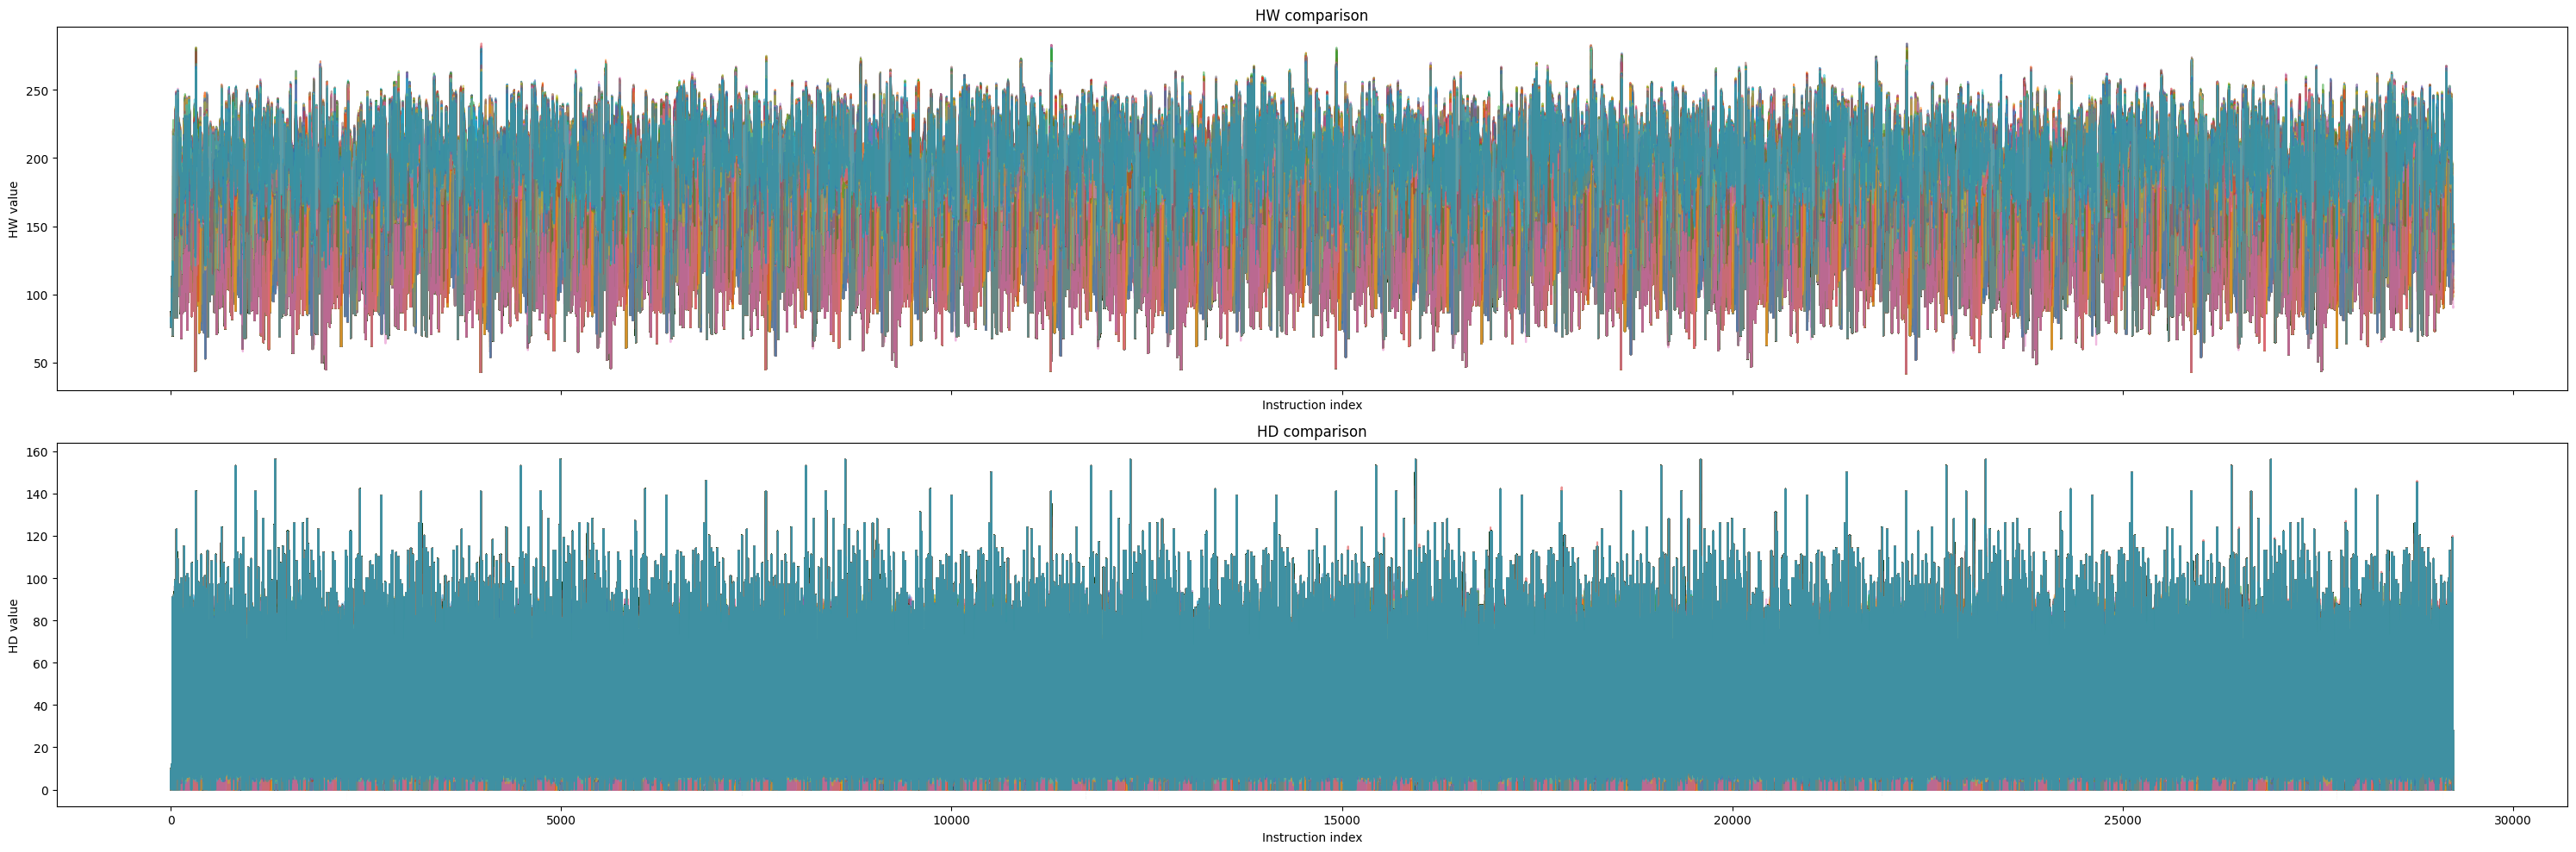

In [ ]:
plt.close('all')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 10), sharex=True)

number_traces = len(data_HW) 
print(f"HW traces loaded: {len(data_HW)}, shape: {data_HW.shape}")
print(f"HD traces loaded: {len(data_HD)}, shape: {data_HD.shape}")

ax1.set_title("HW comparison") 
ax1.set_xlabel("Instruction index")
ax1.set_ylabel("HW value")   

ax2.set_title("HD comparison")
ax2.set_xlabel("Instruction index")
ax2.set_ylabel("HD value")

for ind in range(number_traces):
    ax1.plot(data_HW[ind], alpha=0.5) 
    ax2.plot(data_HD[ind], alpha=0.5)

save_path = os.path.join(result_dir, "traces_plot.png")
plt.savefig(save_path, dpi=200)

plt.tight_layout()
plt.show()

Variance 

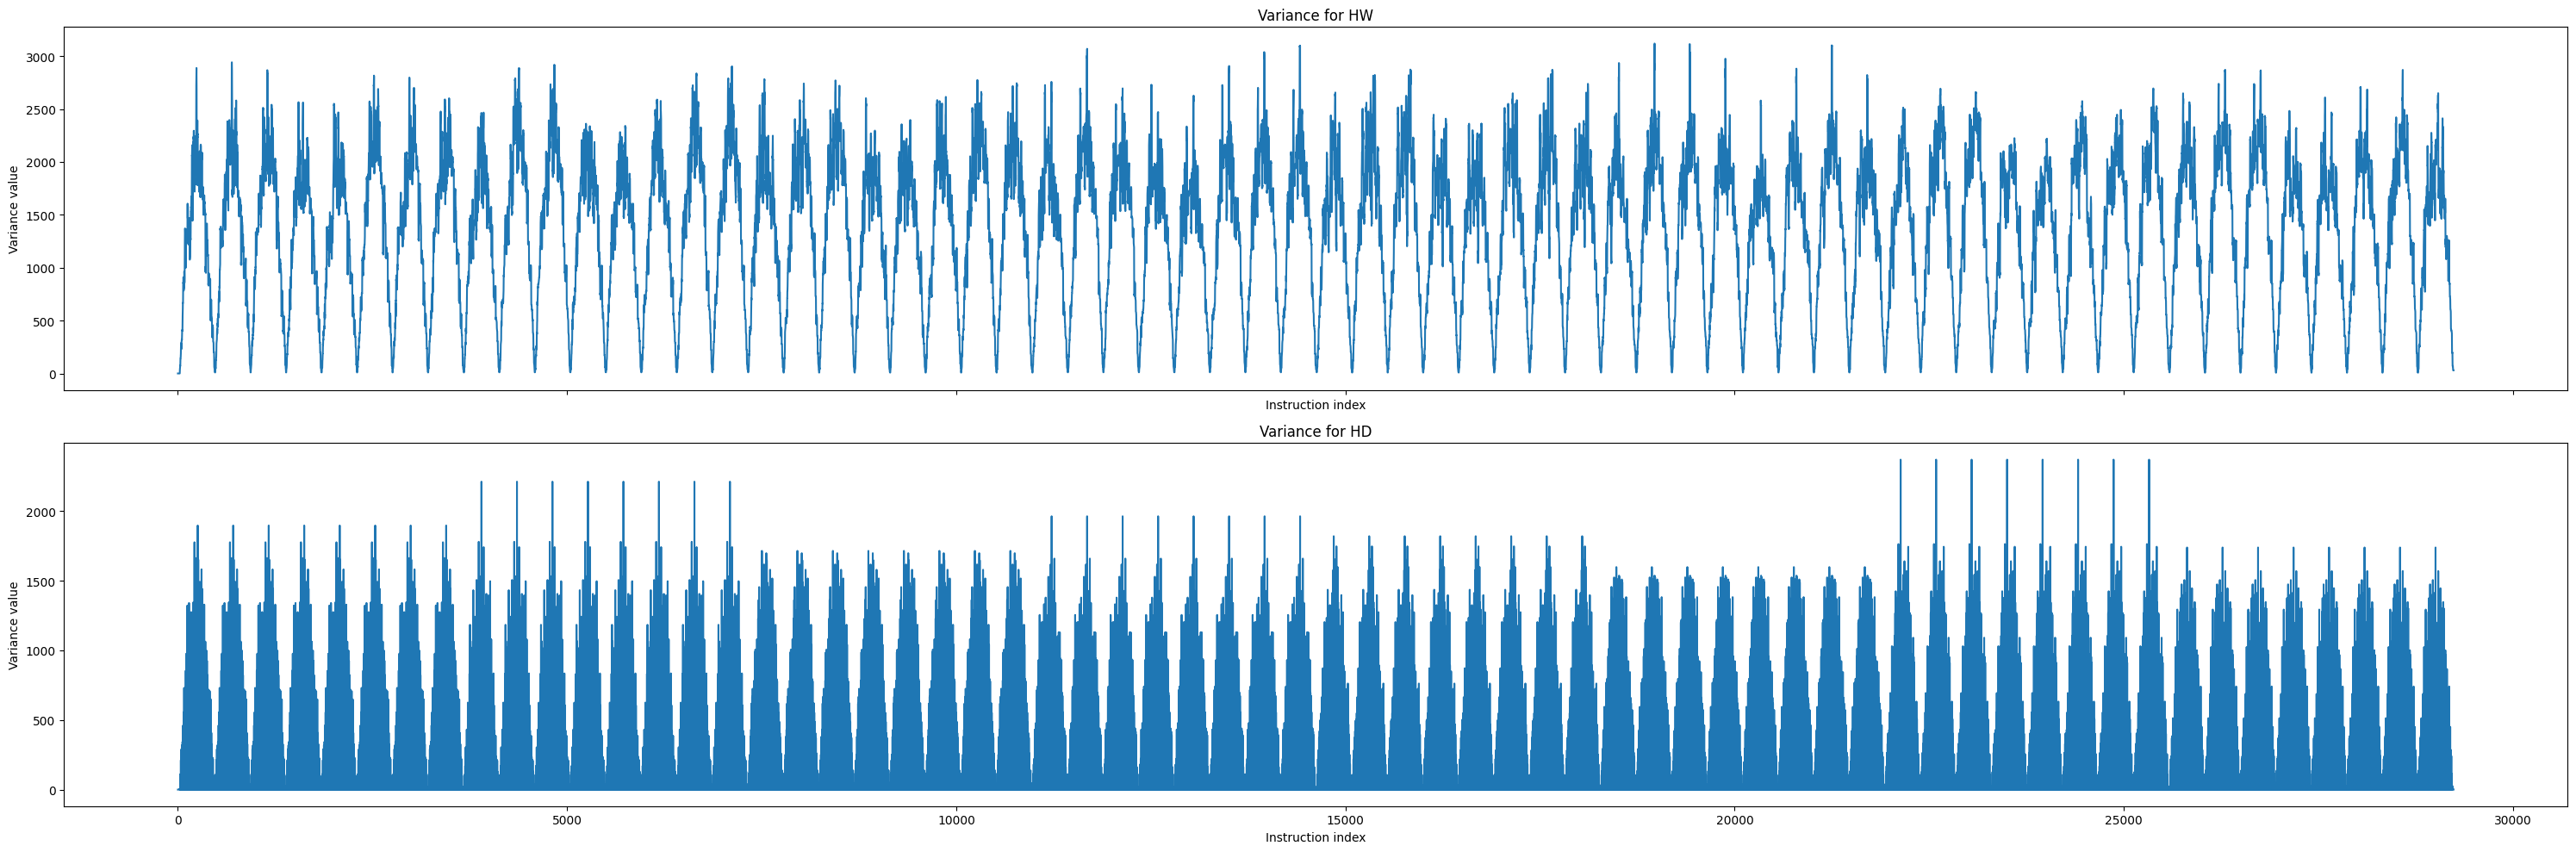

In [ ]:
plt.close('all')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 10), sharex=True)

data_HW = np.load(f'{filename_hw}.npy')
data_HD = np.load(f'{filename_hd}.npy')

var_traces_hw = np.var(data_HW, axis=0)
var_traces_hd = np.var(data_HD, axis=0)

ax1.plot(var_traces_hw)
ax1.set_title("Variance for HW")
ax1.set_xlabel("Instruction index")
ax1.set_ylabel("Variance value")

ax2.plot(var_traces_hd)
ax2.set_title("Variance for HD")
ax2.set_xlabel("Instruction index")
ax2.set_ylabel("Variance value")

save_path = os.path.join(result_dir, "variance_all_traces.png")
plt.savefig(save_path, dpi=200)

plt.tight_layout()
plt.show()


Standard deviation 

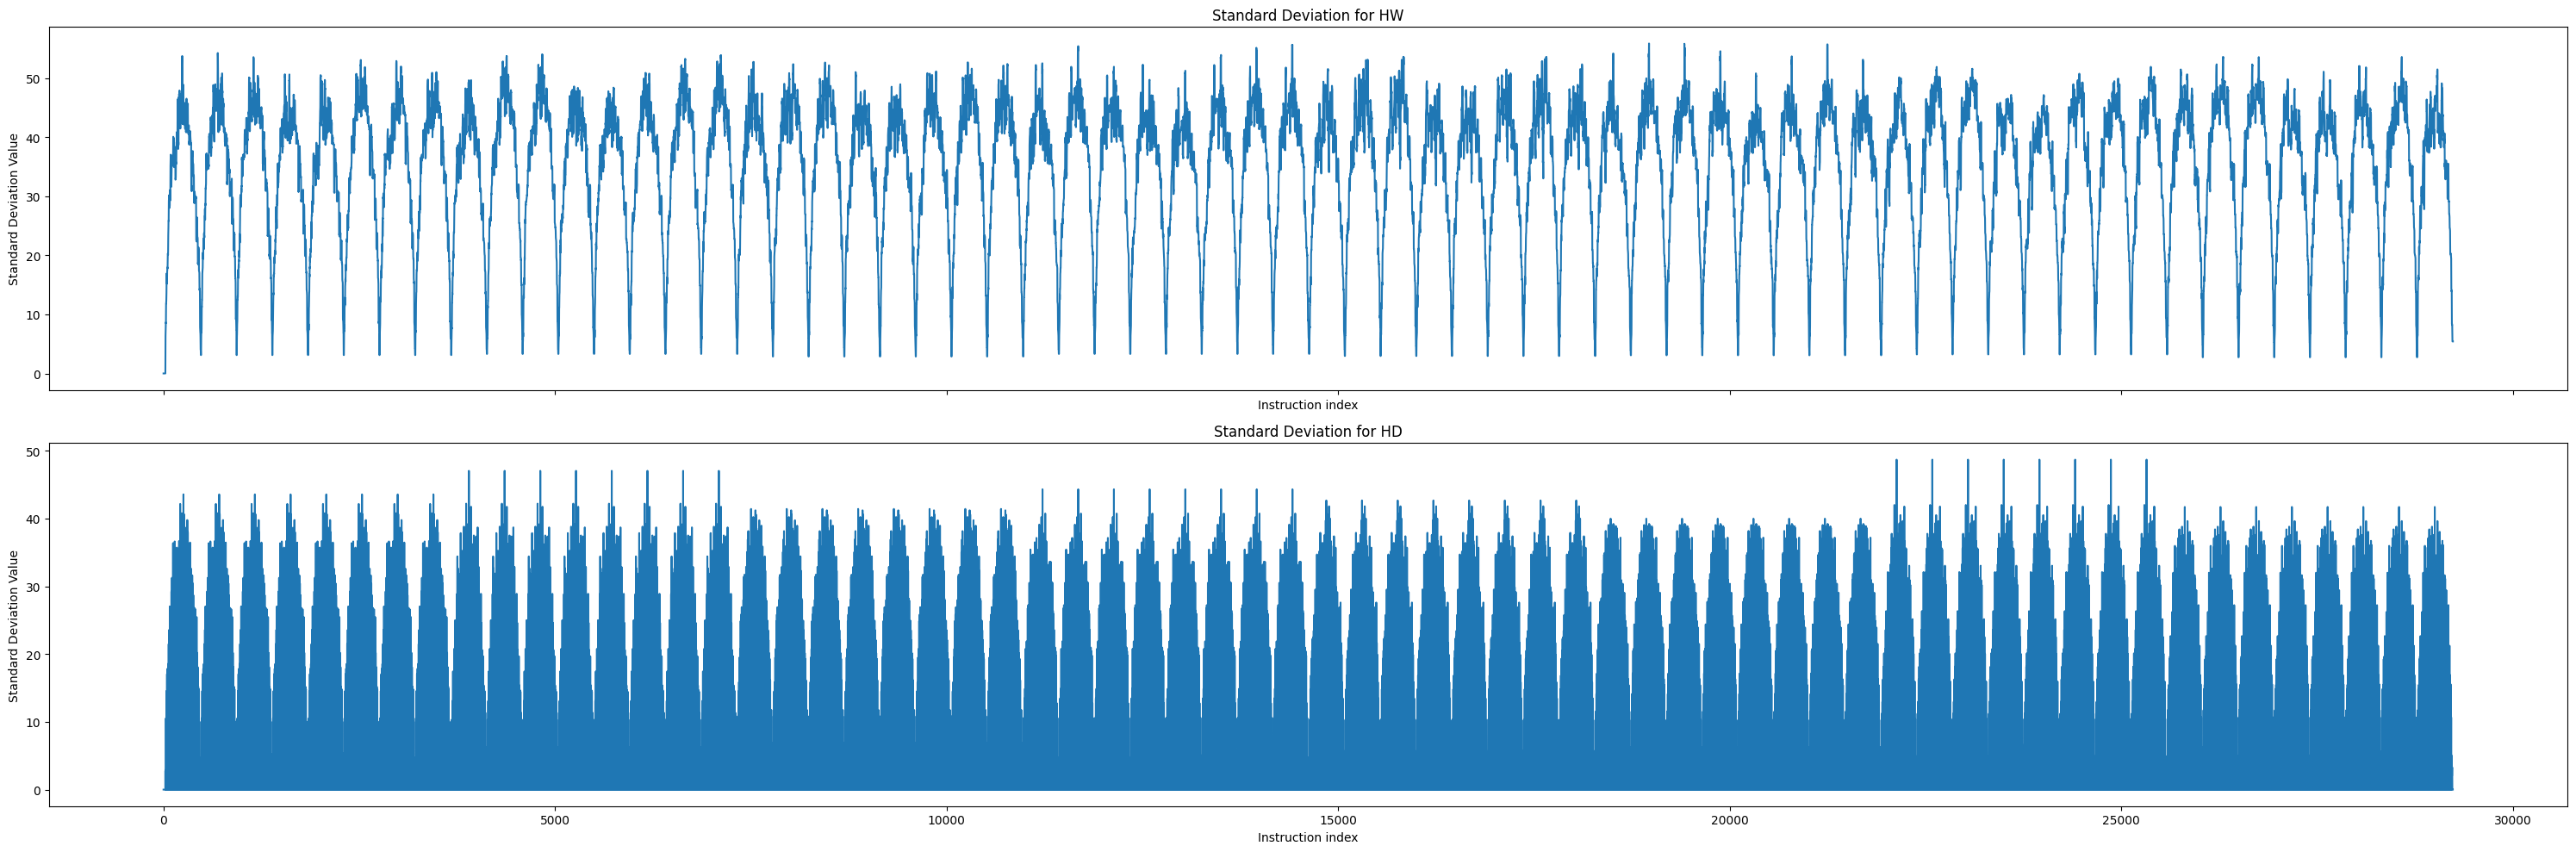

In [ ]:
plt.close('all')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 10), sharex=True)

data_HW = np.load(f'{filename_hw}.npy')
data_HD = np.load(f'{filename_hd}.npy')

std_traces_hw = np.std(data_HW, axis=0)
std_traces_hd = np.std(data_HD, axis=0)

ax1.plot(std_traces_hw)
ax1.set_title("Standard Deviation for HW")
ax1.set_xlabel("Instruction index")
ax1.set_ylabel("Standard Deviation Value")

ax2.plot(std_traces_hd)
ax2.set_title("Standard Deviation for HD")
ax2.set_xlabel("Instruction index")
ax2.set_ylabel("Standard Deviation Value")

save_path = os.path.join(result_dir, "standard_deviation_all_traces.png")
plt.savefig(save_path, dpi=200)

plt.tight_layout()
plt.show()


# Comparison between 2 traces

Initialisation of the 2 traces:

In [26]:
index1 = 0
index2 = 620

pairs = [(0,1), (0,128), (0,256), (0,480), (0,620)]

trace1_HW = data_HW[index1]
trace2_HW = data_HW[index2]

trace1_HD = data_HD[index1]
trace2_HD = data_HD[index2]

HD and HW 

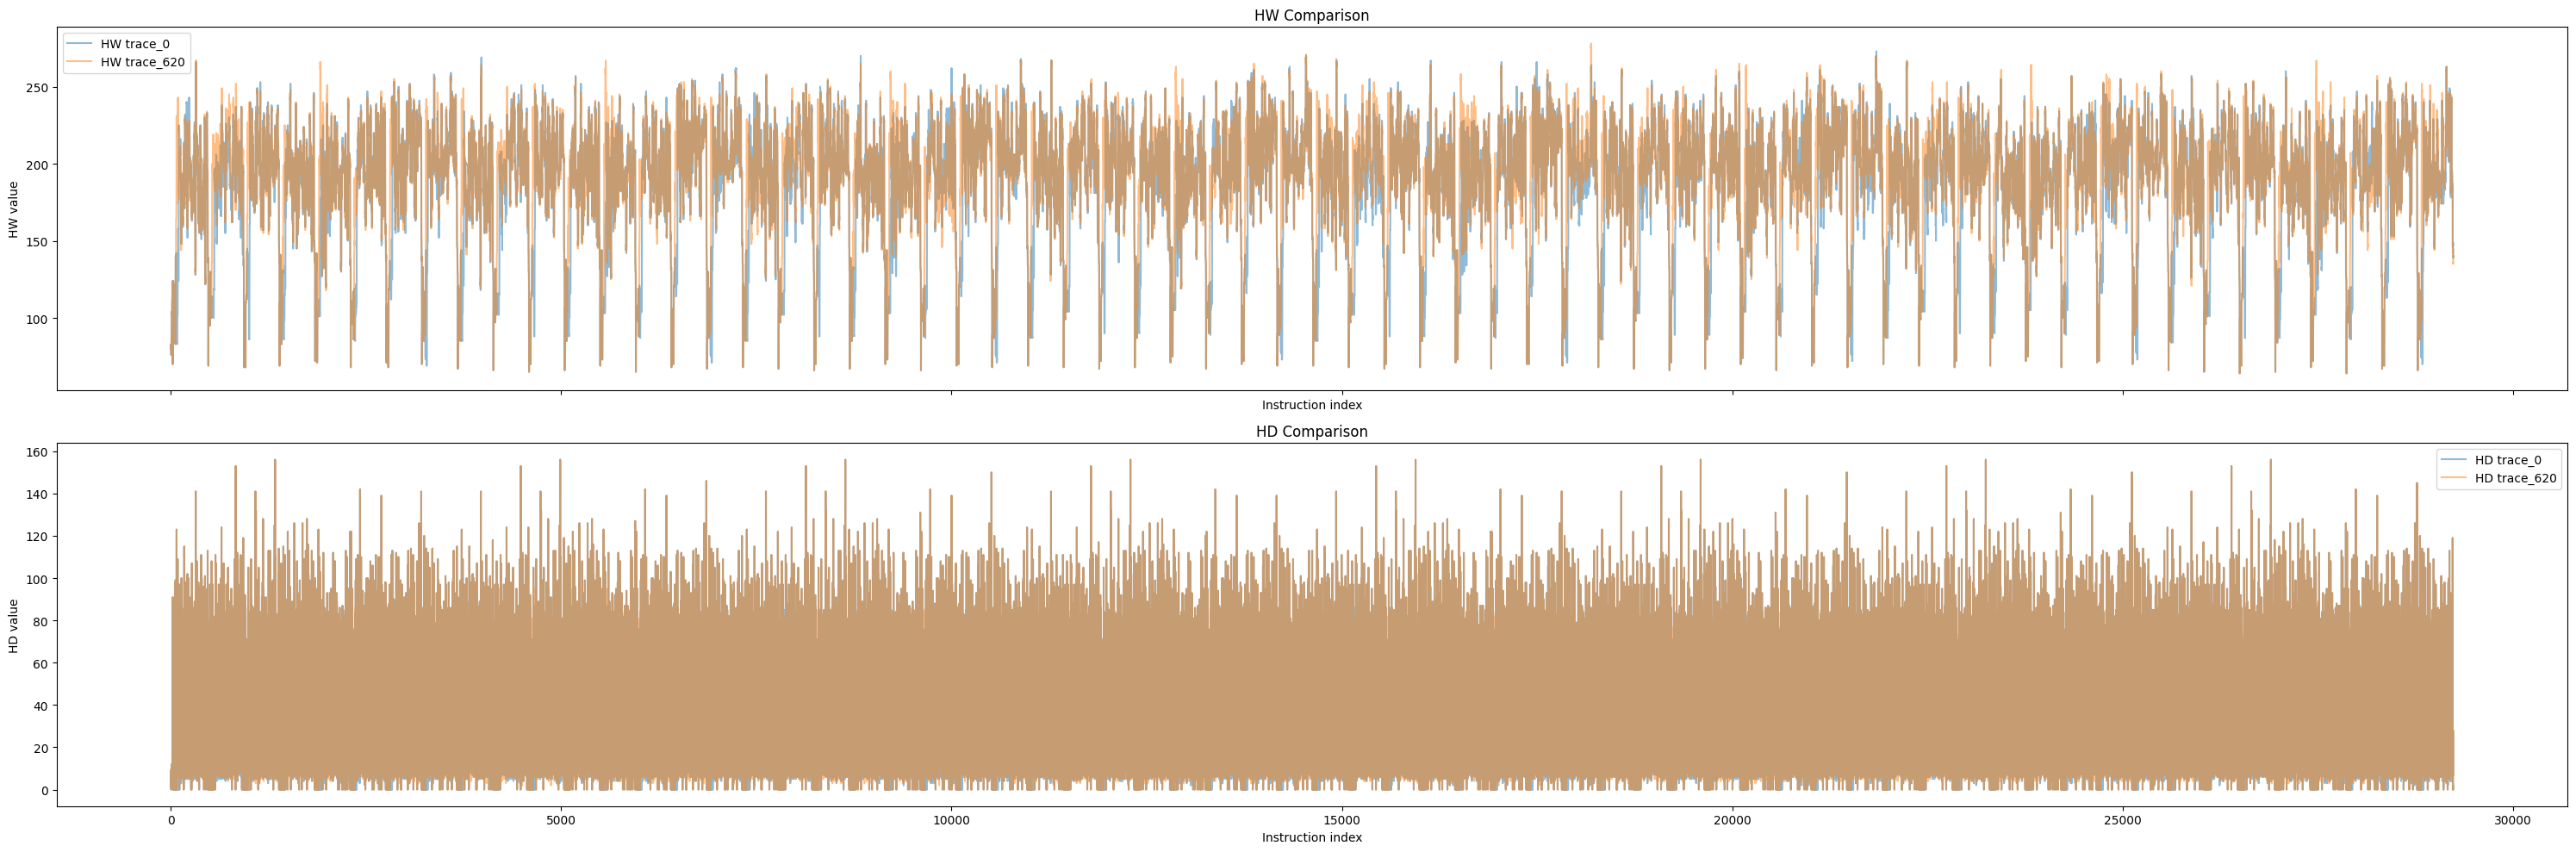

In [ ]:
plt.close('all')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 10), sharex=True)

ax1.plot(trace1_HW, alpha=0.5, label=f"HW trace_{index1}")
ax1.plot(trace2_HW, alpha=0.5, label=f"HW trace_{index2}")
ax1.set_title("HW Comparison")
ax1.set_xlabel("Instruction index")
ax1.set_ylabel("HW value")
ax1.legend()

ax2.plot(trace1_HD, alpha=0.5, label=f"HD trace_{index1}")
ax2.plot(trace2_HD, alpha=0.5, label=f"HD trace_{index2}")
ax2.set_title("HD Comparison")
ax2.set_xlabel("Instruction index")
ax2.set_ylabel("HD value")
ax2.legend()


save_path = os.path.join(result_dir, "hw_and_hd_traces_comparison.png")
plt.savefig(save_path, dpi=200)

plt.tight_layout()
plt.show()


Pointwise difference between the 2 traces:

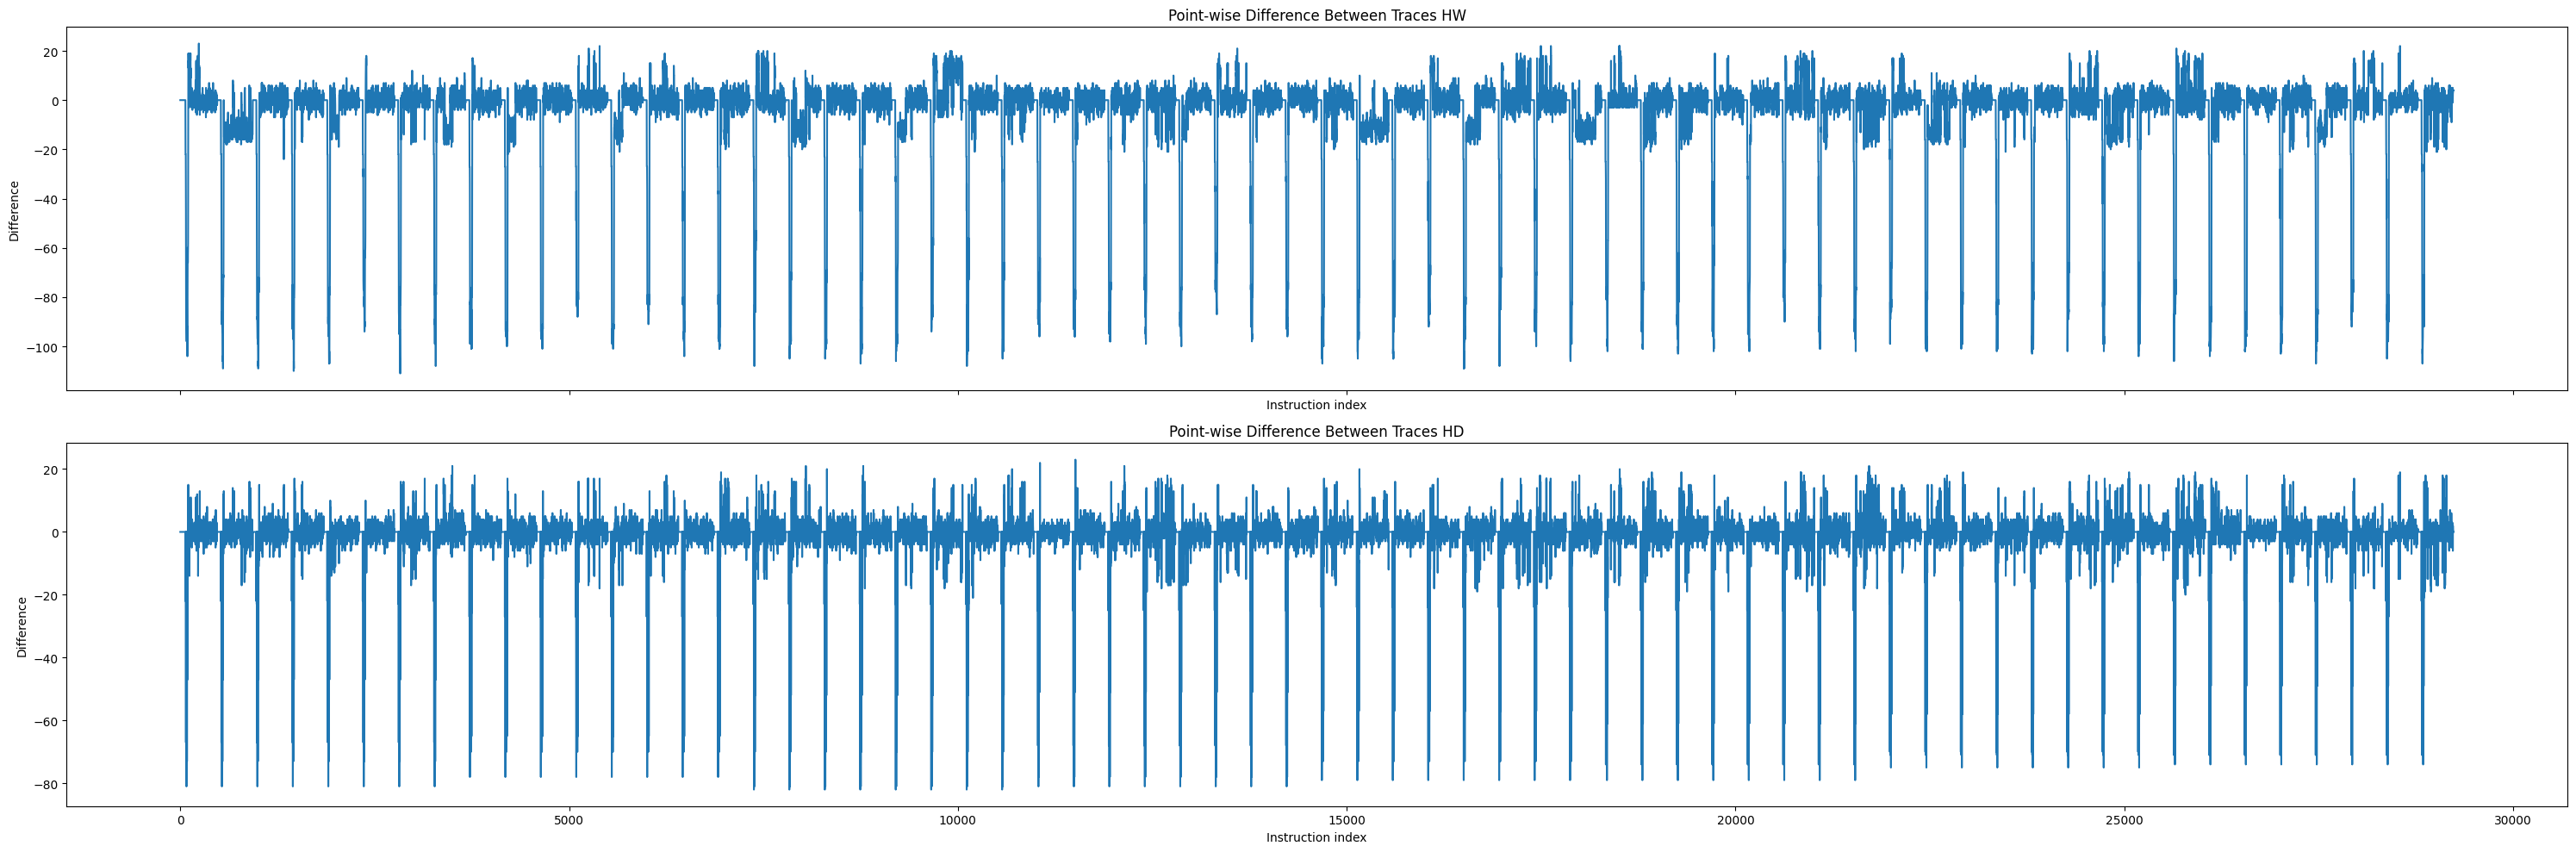

In [ ]:
plt.close('all')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 10), sharex=True)

diff_HW = trace1_HW - trace2_HW
diff_HD = trace1_HD - trace2_HD

ax1.set_title("Point-wise Difference Between Traces HW")
ax1.set_xlabel("Instruction index")
ax1.set_ylabel("Difference")
ax1.plot(diff_HW)

ax2.set_title("Point-wise Difference Between Traces HD")
ax2.set_xlabel("Instruction index")
ax2.set_ylabel("Difference")
ax2.plot(diff_HD)


save_path = os.path.join(result_dir, "pointwise_difference.png")
plt.savefig(save_path, dpi=200)

plt.tight_layout()
plt.show()

Correlation 

Correlation HW (0,1) = 0.9495
Correlation HW (0,128) = 0.9118
Correlation HW (0,256) = 0.7854
Correlation HW (0,480) = 0.7434
Correlation HW (0,620) = 0.8512
Correlation HD (0,1) = 0.9879
Correlation HD (0,128) = 0.9809
Correlation HD (0,256) = 0.9531
Correlation HD (0,480) = 0.9573
Correlation HD (0,620) = 0.9739


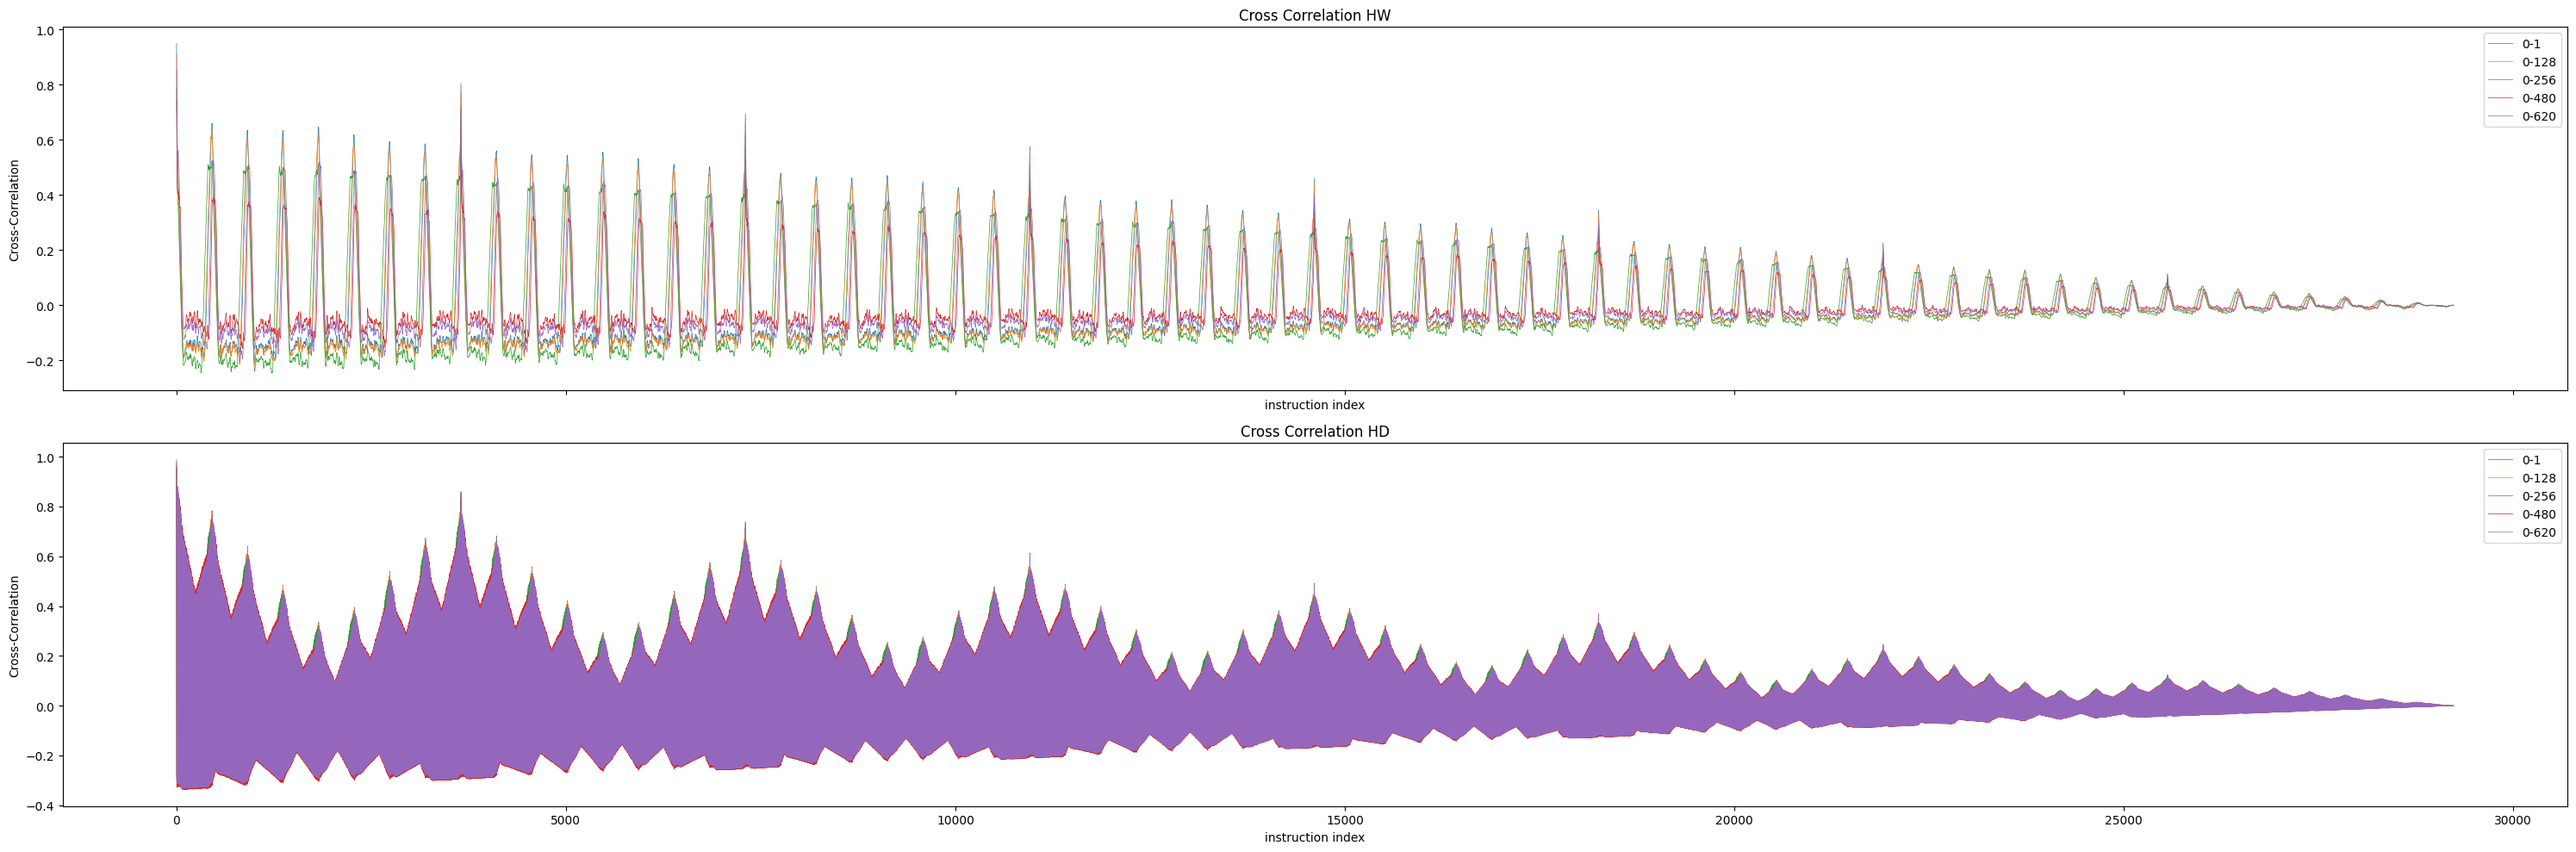

In [29]:
def cross_correlation(trace1, trace2):
    n = min(len(trace1), len(trace2))
    trace1 = trace1[:n]
    trace2 = trace2[:n]
    return np.correlate(trace1 - trace1.mean(), trace2 - trace2.mean(), mode='full')[n-1:] / (trace1.std() * trace2.std() * n)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 10), sharex=True)

# HW
for i, j in pairs:
    trace1_HW = data_HW[i]
    trace2_HW = data_HW[j]

    n = min(len(trace1_HW), len(trace2_HW))
    trace1_HW = trace1_HW[:n]
    trace2_HW = trace2_HW[:n]

    corr_hw = np.corrcoef(trace1_HW, trace2_HW)[0, 1]
    print(f"Correlation HW ({i},{j}) = {corr_hw:.4f}")

    ax1.plot(cross_correlation(trace1_HW, trace2_HW), lw=0.5, label=f"{i}-{j}")

ax1.set_title("Cross Correlation HW")
ax1.set_ylabel("Cross-Correlation")
ax1.set_xlabel("instruction index")
ax1.legend()

# HD
for i, j in pairs:
    trace1_HD = data_HD[i]
    trace2_HD = data_HD[j]

    n = min(len(trace1_HD), len(trace2_HD))
    trace1_HD = trace1_HD[:n]
    trace2_HD = trace2_HD[:n]

    corr_hd = np.corrcoef(trace1_HD, trace2_HD)[0, 1]
    print(f"Correlation HD ({i},{j}) = {corr_hd:.4f}")

    ax2.plot(cross_correlation(trace1_HD, trace2_HD), lw=0.5, label=f"{i}-{j}")

ax2.set_title("Cross Correlation HD")
ax2.set_ylabel("Cross-Correlation")
ax2.set_xlabel("instruction index")
ax2.legend()


save_path = os.path.join(result_dir, "correlation_between_2_traces.png")
plt.savefig(save_path, dpi=200)

plt.tight_layout()
plt.show()

# Sample analysis 

Initializing  

In [30]:
import csv
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from multiprocessing import Pool
import re

In [ ]:
def HW(a):
    return a.count('1')


def HD(a,b):
    return sum(c1 != c2 for c1, c2 in zip(a, b)) 


def hex_to_bin32(x):
    return bin(int(x, 0))[2:].rjust(32, '0')


def create_HD_trace(filename, cols):
    df = pd.read_csv(filename)
    df.fillna('0x0', inplace=True)

    reg_bin = []
    for col in cols:
        reg_bin.append(df[col].apply(hex_to_bin32).tolist())

    number_instructions = len(reg_bin[0])
    hd_ref = np.zeros((number_instructions - 1, len(cols)))

    for col in range(len(cols)):
        for i in range(number_instructions - 1):
            hd_ref[i, col] = HD(reg_bin[col][i], reg_bin[col][i + 1])

    return np.sum(hd_ref, axis=1)


def create_HW_trace(filename,cols):
      """
      reads an execution trace in csv format 
      returns 
      - the hamming weight of  the content of all registers for each instruction
      - the total number of instructions

      """
      df = pd.read_csv(filename)
      df.fillna('0x0', inplace=True)
      #cols = ['zero', 'ra', 'sp', 'gp', 'tp', 't0', 't1','t2', 's0', 's1', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 's2',
      #  's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 't3', 't4','t5', 't6']
     #cols = ['t1', 's0', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 't3']
      # convert hex register values to binary and decimal values
      reg_bin=[]
      for col in cols:
          reg_bin.append(df[col].apply(hex_to_bin32).tolist())

      number_instructions = len(reg_bin[0])# number of instructions
      hw_ref = np.zeros((number_instructions ,len(cols)))
      for col in range(len(cols)):
        for i in range(number_instructions):
            hw_ref[i,col] = HW(reg_bin[col][i])
      return  np.sum(hw_ref,axis=1)

def get_trace_index_from_filename(file_path):
    """
    This function should get the index of the trace (0,1,2, etc. so trace_0.csv has index 0)
    """
    match = re.search(r'trace_(\d+)\.csv$', file_path.name)
    if match is None:
        raise ValueError(f"Could not extract trace index from filename: {file_path}")
    return int(match.group(1))


def create_grouped_npy_files(result_dir, folder, leakage_model, cols):
    """
    This should should read the csv file that are in RUN_{index} and group them based on the index 
    """
    print(f"Creating grouped simulation traces for model: {leakage_model}")
    os.makedirs(result_dir, exist_ok=True)
    # find csv files recursively
    files = sorted(Path(folder).glob('Run_*/*.csv'))
    print(f"There should {len(files)} files created")

    if len(files) == 0:
        print(f"[ERROR] No csv files found in nested Run_* folders under: {folder}")
        return

    grouped_traces = {} 

    for count, file in enumerate(files):
   
        print(f"Trace {count}: {file}")

        trace_index = get_trace_index_from_filename(file)

        if leakage_model == 'HW':
            trace = create_HW_trace(file, cols)
        elif leakage_model == 'HD':
            trace = create_HD_trace(file, cols)
        if trace_index not in grouped_traces:
            grouped_traces[trace_index] = []

        count+=1
        grouped_traces[trace_index].append(trace)

    # save one npy per trace index
    for trace_index, trace_list in grouped_traces.items():
        # make all traces same length inside the same group
        min_len = min(len(t) for t in trace_list)
        vectors_array = np.array([t[:min_len] for t in trace_list])

        output_path = os.path.join(result_dir, f"{leakage_model}_trace_{trace_index}.npy")
        np.save(output_path, vectors_array)

        print(f"Saved {output_path} with shape {vectors_array.shape}")

    print(f"Finished creating grouped files for {leakage_model}")

In [32]:

selected_registers= ['r0','r1','r2','r3','r4','r5','r6','r7','r8','r9','r10','r11','r12','sp','lr']


In [33]:
# the folder from where it reads the execution traces
folder = "output_decapsulation_sample_TRIM"
# where it will output the resulting files
result_dir = "Results_decapsulation_sample"
os.makedirs(result_dir, exist_ok=True)

selected_registers = [
    'r0','r1','r2','r3','r4','r5','r6','r7',
    'r8','r9','r10','r11','r12','sp','lr'
]

unaltered_index = 0
other_index = None

create_grouped_npy_files(result_dir, folder, 'HW', selected_registers)
create_grouped_npy_files(result_dir, folder, 'HD', selected_registers)

Creating grouped simulation traces for model: HW
There should 55 files created
Trace 0: output_decapsulation_sample_TRIM/Run_1/trace_0.csv
Trace 1: output_decapsulation_sample_TRIM/Run_1/trace_1.csv
Trace 2: output_decapsulation_sample_TRIM/Run_1/trace_128.csv
Trace 3: output_decapsulation_sample_TRIM/Run_1/trace_16.csv
Trace 4: output_decapsulation_sample_TRIM/Run_1/trace_2.csv
Trace 5: output_decapsulation_sample_TRIM/Run_1/trace_256.csv
Trace 6: output_decapsulation_sample_TRIM/Run_1/trace_32.csv
Trace 7: output_decapsulation_sample_TRIM/Run_1/trace_4.csv
Trace 8: output_decapsulation_sample_TRIM/Run_1/trace_512.csv
Trace 9: output_decapsulation_sample_TRIM/Run_1/trace_64.csv
Trace 10: output_decapsulation_sample_TRIM/Run_1/trace_8.csv
Trace 11: output_decapsulation_sample_TRIM/Run_2/trace_0.csv
Trace 12: output_decapsulation_sample_TRIM/Run_2/trace_1.csv
Trace 13: output_decapsulation_sample_TRIM/Run_2/trace_128.csv
Trace 14: output_decapsulation_sample_TRIM/Run_2/trace_16.csv
Trac

Information about the traces 

In [34]:
def information(name, data):
    print(f"\nInformation about: {name}")
    print(f"The shape of the data is: {data.shape}")
    print(f"The type of the data is: {data.dtype}")
    print(f"The first 2 traces are:\n{data[:2]}")
    print(f"If there are any NaN variables: {np.isnan(data).any()}")

data_HW = {}
for file in sorted(Path(result_dir).glob("HW_trace_*.npy")):
    idx = int(file.stem.split("_")[-1])
    data_HW[idx] = np.load(file)
    information(f"HW_trace_{idx}", data_HW[idx])

data_HD = {}
for file in sorted(Path(result_dir).glob("HD_trace_*.npy")):
    idx = int(file.stem.split("_")[-1])
    data_HD[idx] = np.load(file)
    information(f"HD_trace_{idx}", data_HD[idx])


Information about: HW_trace_0
The shape of the data is: (5, 29237)
The type of the data is: float64
The first 2 traces are:
[[ 80.  82.  83. ... 156. 146. 147.]
 [ 80.  82.  83. ... 154. 144. 145.]]
If there are any NaN variables: False

Information about: HW_trace_1
The shape of the data is: (5, 29237)
The type of the data is: float64
The first 2 traces are:
[[ 80.  82.  83. ... 157. 147. 148.]
 [ 80.  82.  83. ... 151. 141. 142.]]
If there are any NaN variables: False

Information about: HW_trace_128
The shape of the data is: (5, 29237)
The type of the data is: float64
The first 2 traces are:
[[ 80.  82.  83. ... 158. 148. 149.]
 [ 80.  82.  83. ... 155. 145. 146.]]
If there are any NaN variables: False

Information about: HW_trace_16
The shape of the data is: (5, 29237)
The type of the data is: float64
The first 2 traces are:
[[ 80.  82.  83. ... 157. 147. 148.]
 [ 80.  82.  83. ... 154. 144. 145.]]
If there are any NaN variables: False

Information about: HW_trace_2
The shape of t

Group the traces: 

1. Group traces based o the prefix (HD or HW) and index 

In [35]:
def load_trace(result_dir, prefix, idx):
    path = Path(result_dir) / f"{prefix}_trace_{idx}.npy"
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path)


2. Compute SNR (Sound Noise Ratio as https://chipwhisperer.readthedocs.io/en/5.7.0/analyzer-api.html)

In [36]:
def compute_snr(trace1, trace2):
    """
    SNR = (mu_a - mu_b)^2 / (var_a + var_b)
    """
    min_len = min(trace1.shape[1], trace2.shape[1])

    a = trace1[:, :min_len]
    b = trace2[:, :min_len]

    mu_a = np.mean(a, axis=0)
    mu_b = np.mean(b, axis=0)

    var_a = np.var(a, axis=0)
    var_b = np.var(b, axis=0)

    denom = var_a + var_b

    snr = np.zeros_like(mu_a)
    mask = denom > 0
    snr[mask] = ((mu_a - mu_b)[mask] ** 2) / denom[mask]

    return snr

3. Plot 

In [ ]:
def plot_single(snr, title, save_path=None):
    plt.close('all')
    plt.figure(figsize=(20, 6))
    plt.plot(snr)
    plt.title(title)
    plt.xlabel("Instruction index")
    plt.ylabel("SNR")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


def plot_combined(snr_dict, title, save_path=None):
    n = len(snr_dict)
    print(f"Number of traces to plot: {n}")
    print(f"Trace lengths: { {k: len(v) for k, v in snr_dict.items()} }")

    plt.close('all')
    plt.figure(figsize=(20, 6))

    # Spread alpha evenly across traces so none go negative or zero
    sorted_items = sorted(snr_dict.items(), key=lambda x: len(x[1]), reverse=True)
    alpha_step = 0.4 / n

    for i, (label, snr) in enumerate(sorted_items):
        alpha_local = max(0.5, 1.0 - i * alpha_step)
        print(f"Plotting '{label}': length={len(snr)}, alpha={alpha_local:.2f}")
        plt.plot(snr, label=label, alpha=alpha_local, linewidth=0.8)

    plt.title(title)
    plt.xlabel("Instruction index")
    plt.ylabel("SNR")
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


4. Call functions:

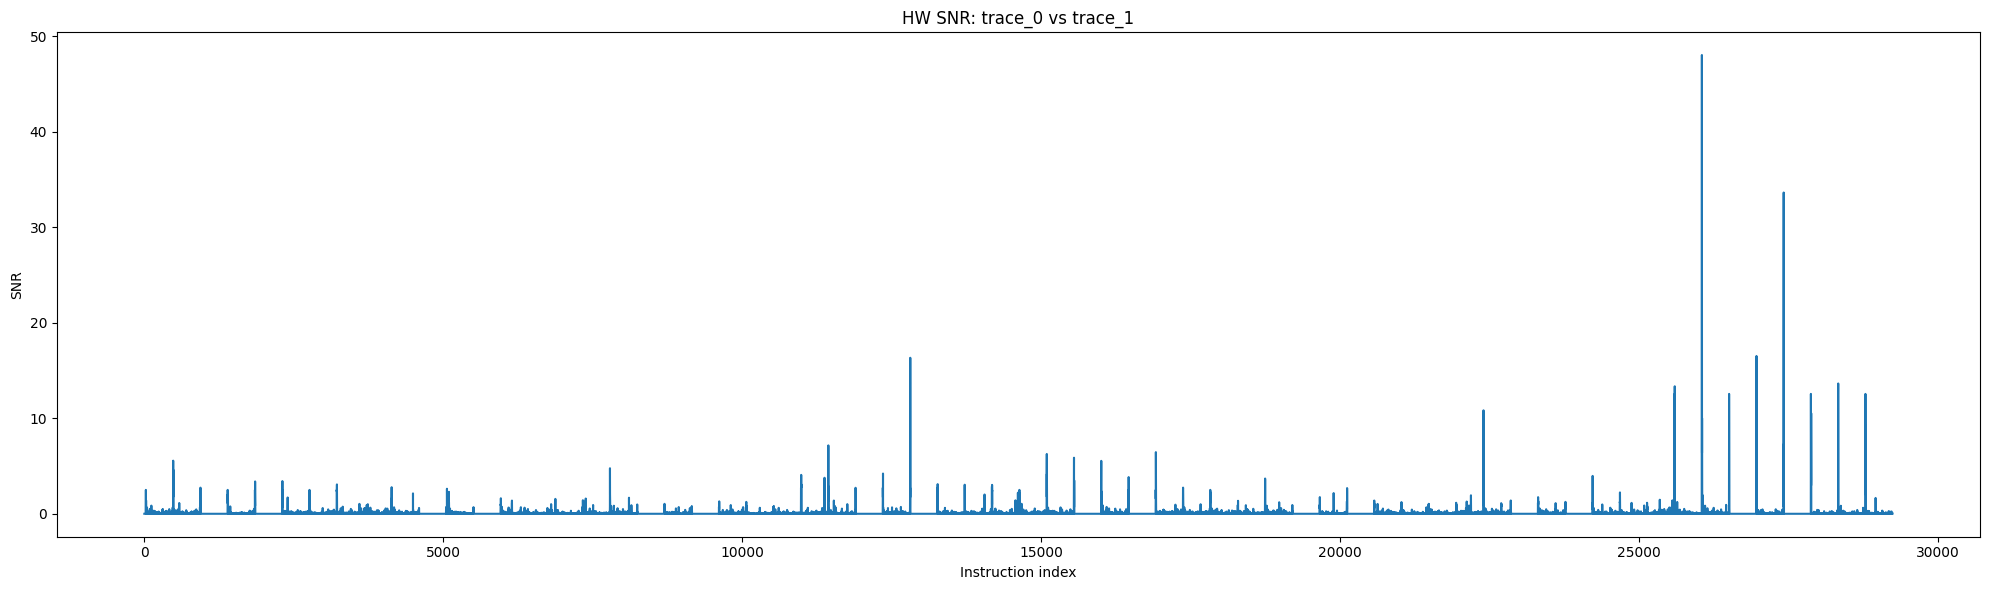

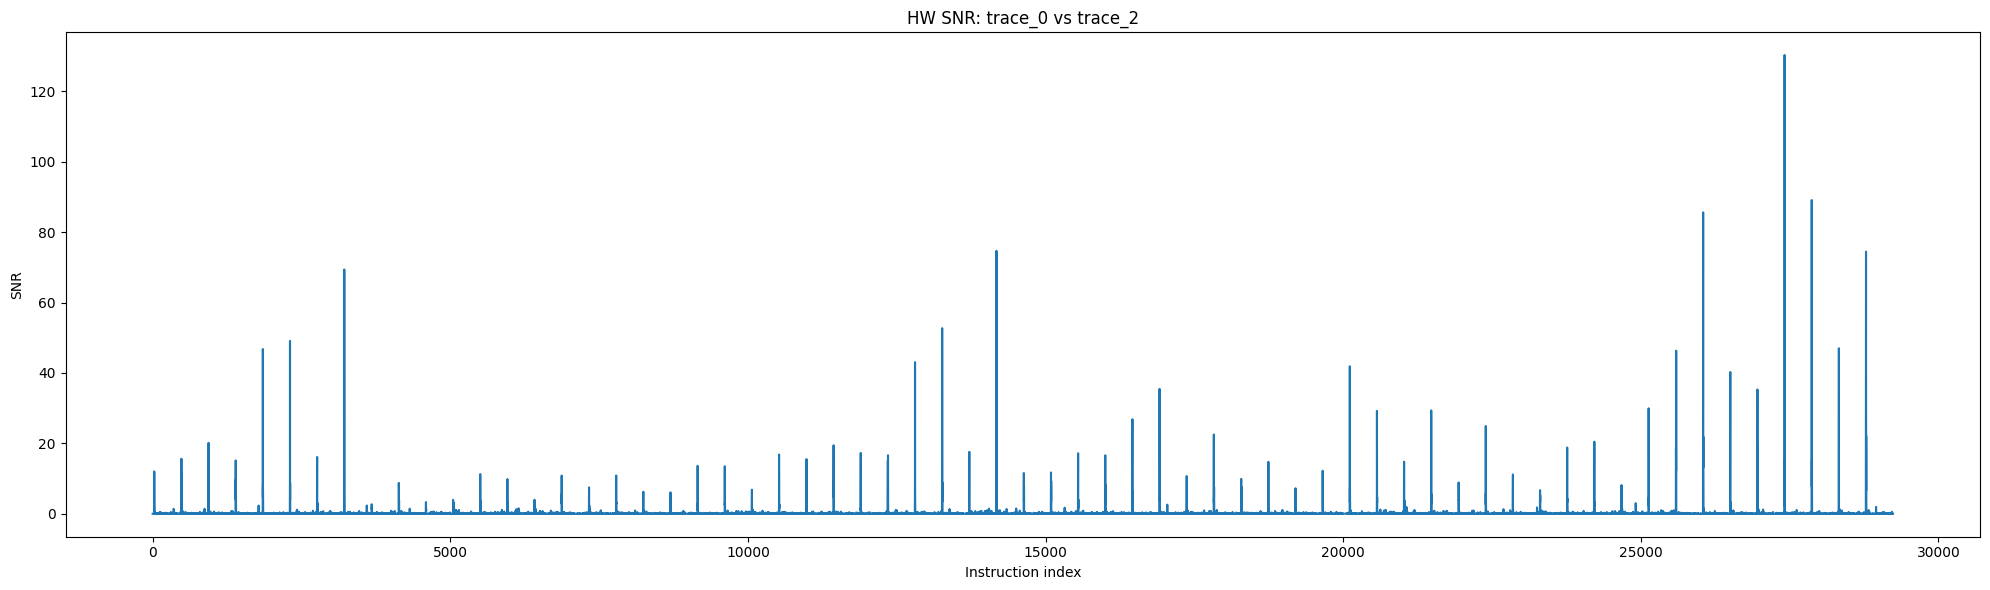

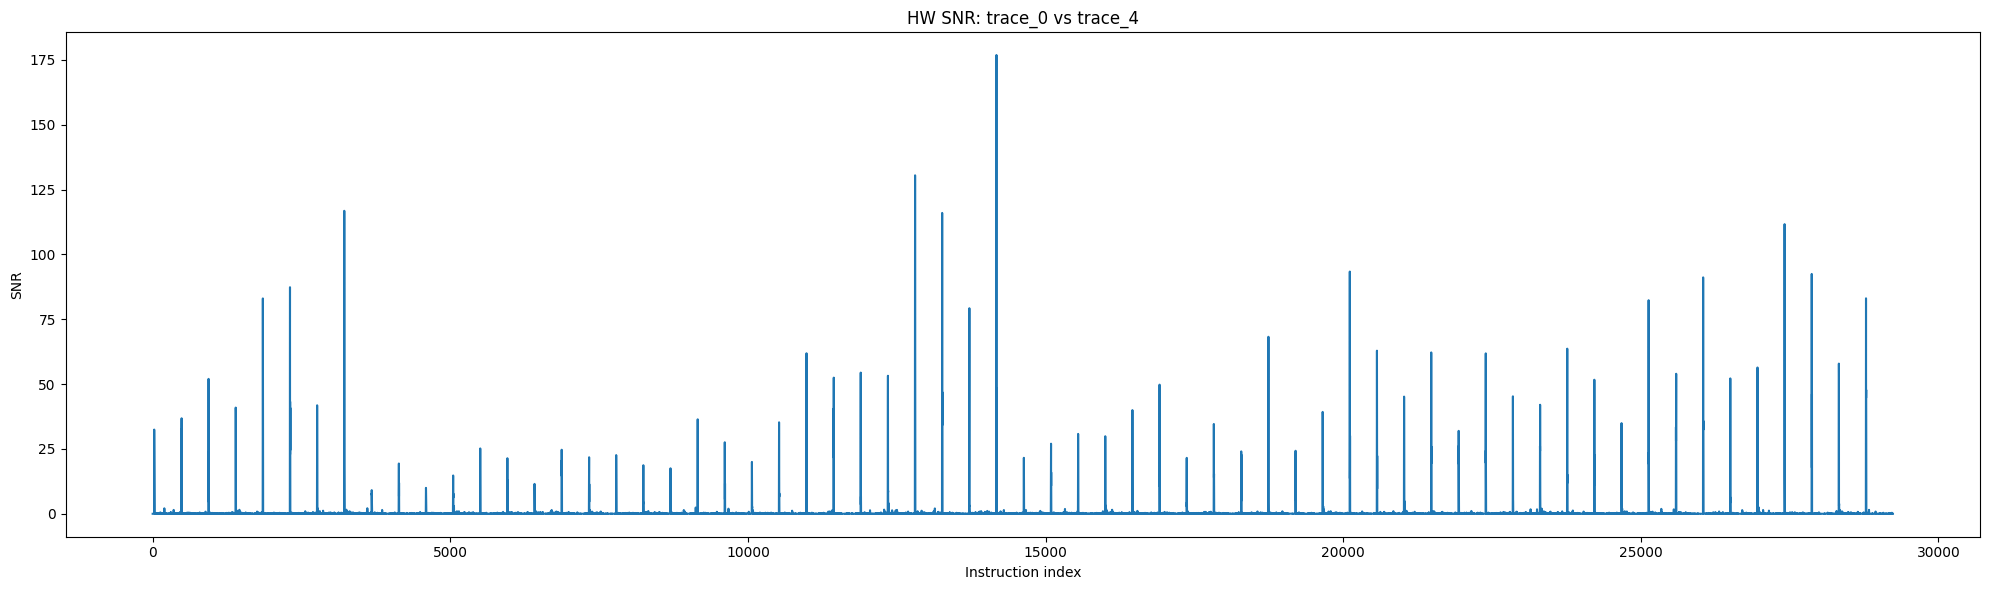

Number of traces to plot: 3
Trace lengths: {'trace_0 vs trace_1': 29237, 'trace_0 vs trace_2': 29237, 'trace_0 vs trace_4': 29237}
Plotting 'trace_0 vs trace_1': length=29237, alpha=1.00
Plotting 'trace_0 vs trace_2': length=29237, alpha=0.87
Plotting 'trace_0 vs trace_4': length=29237, alpha=0.73


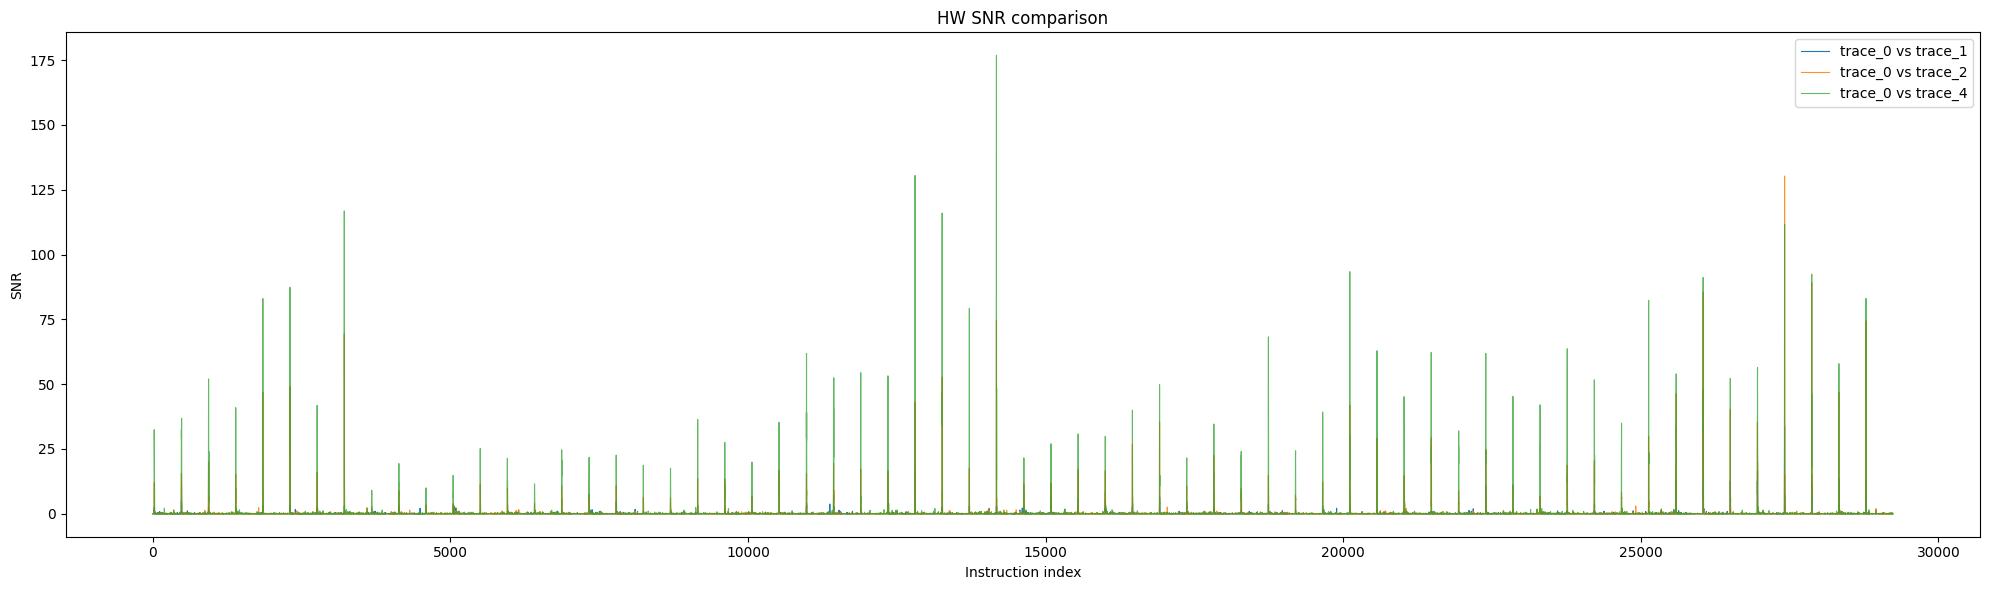

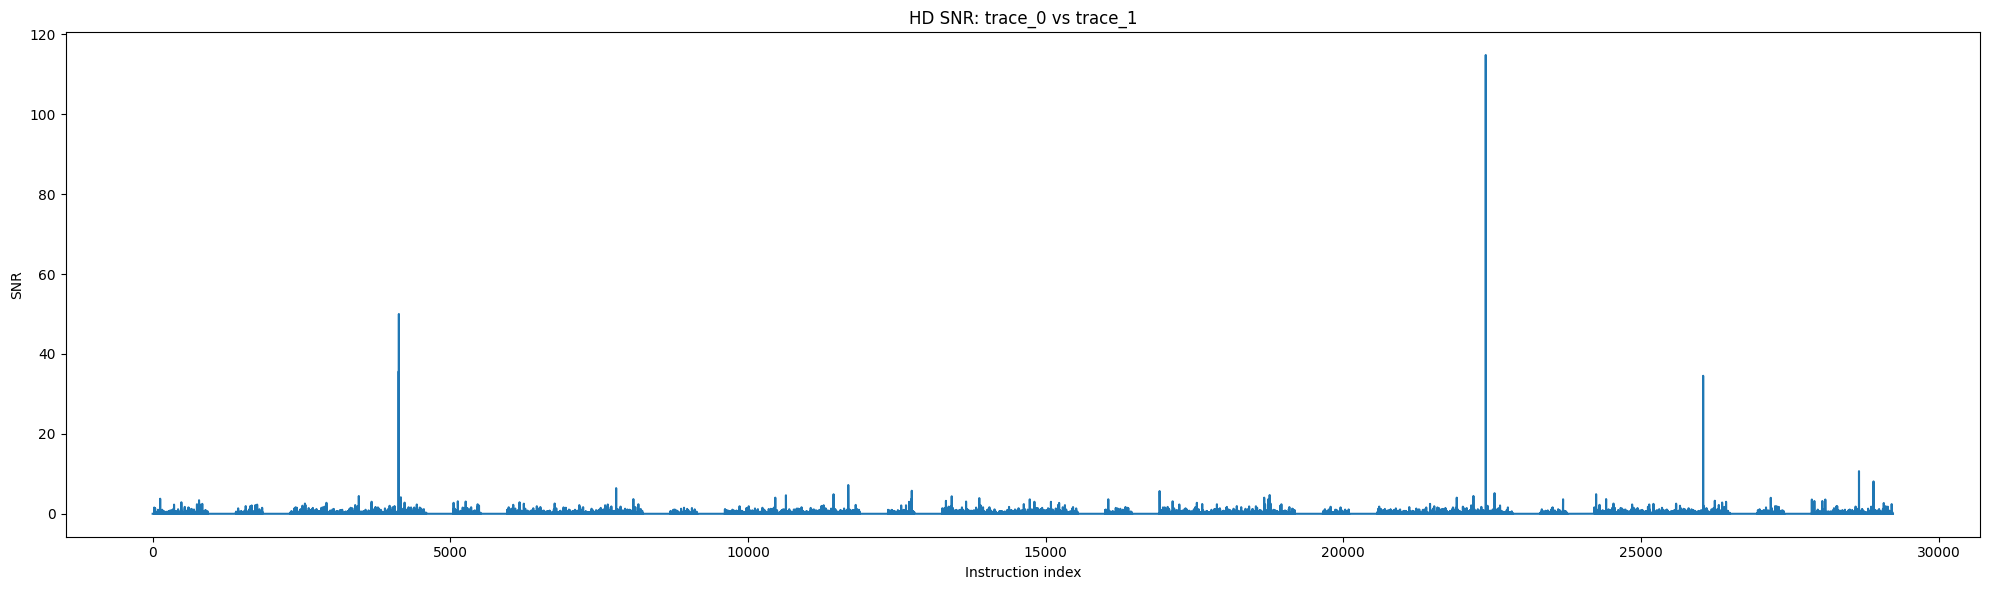

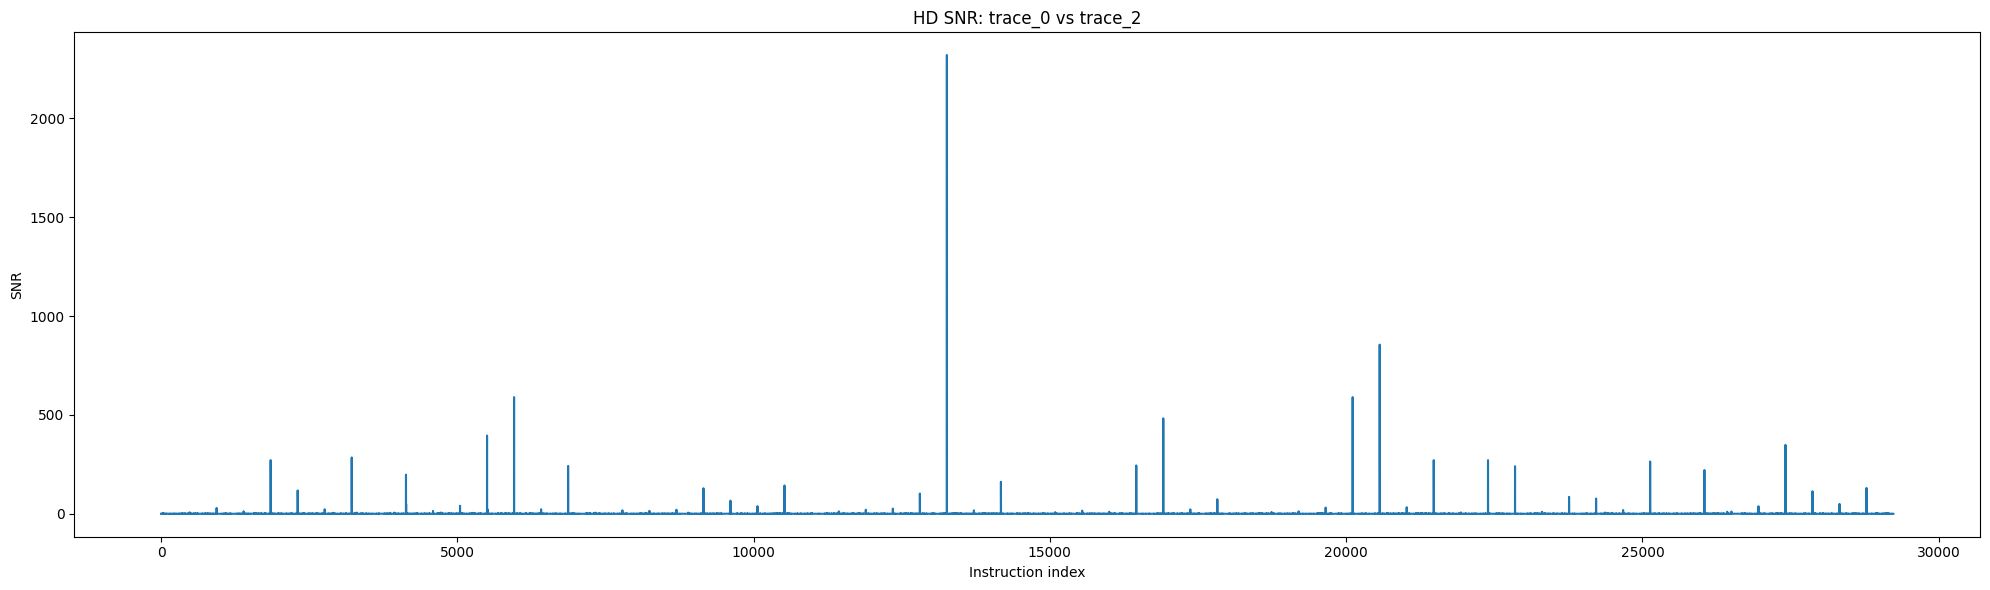

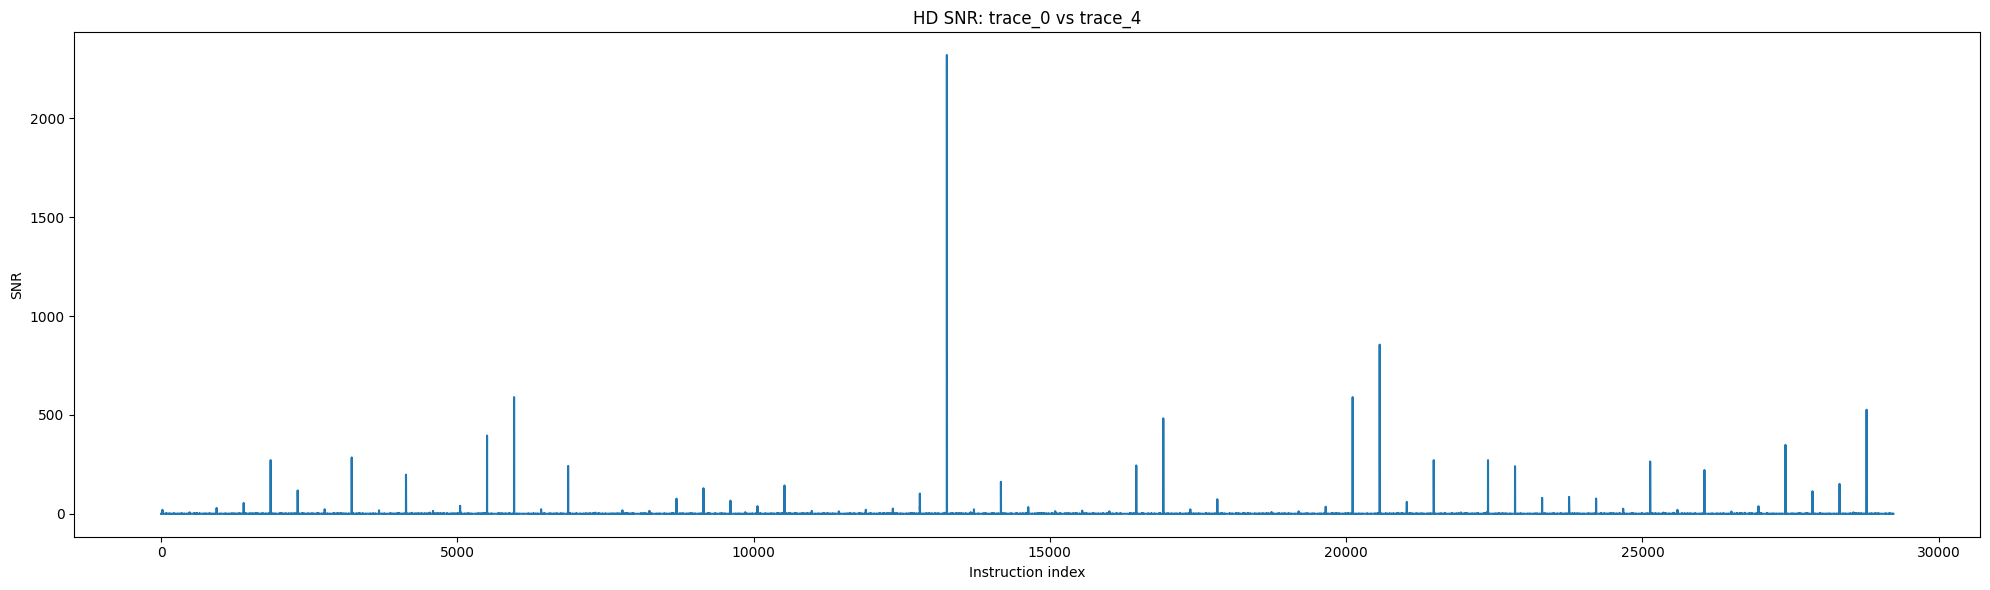

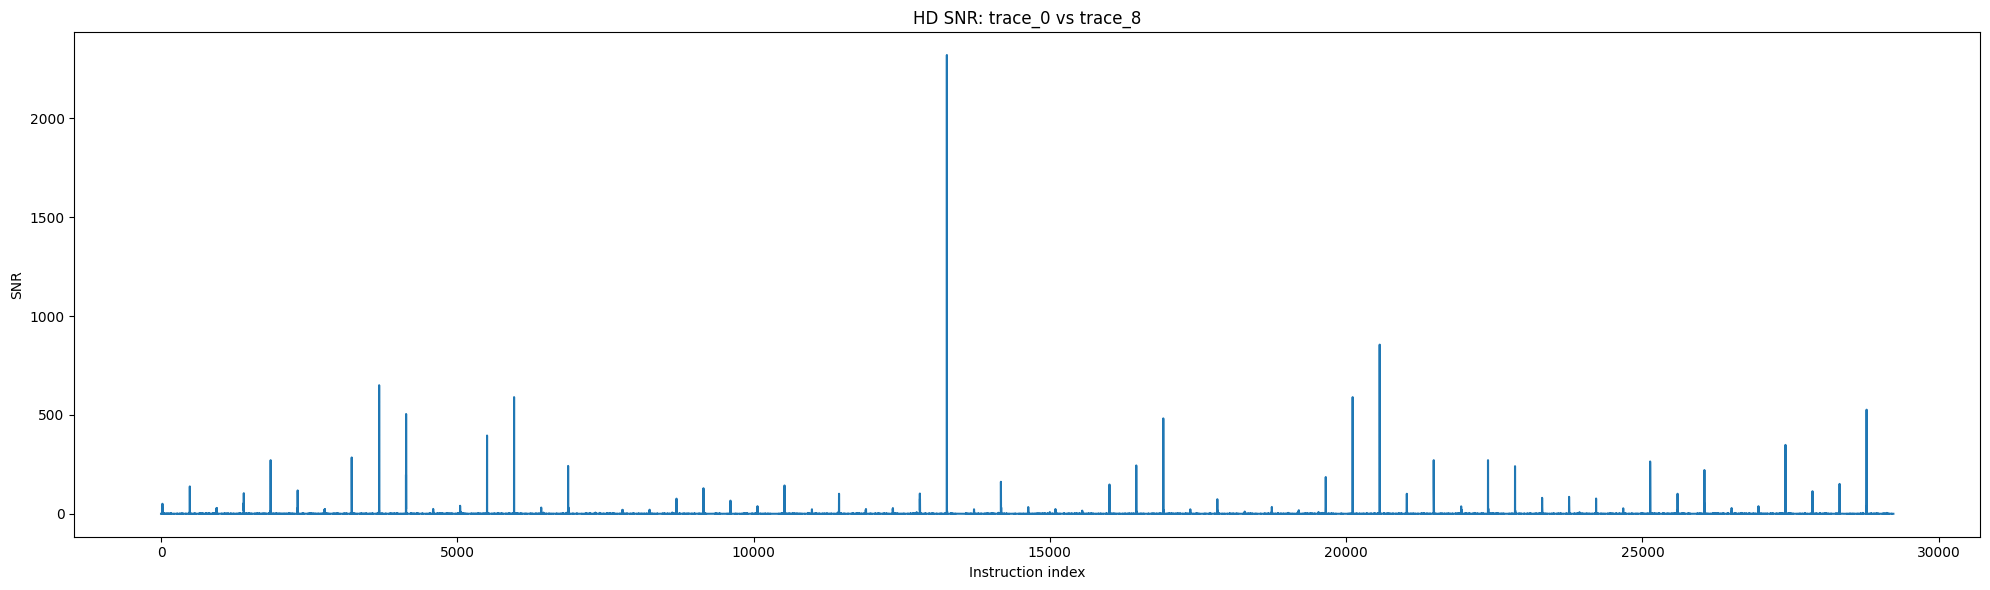

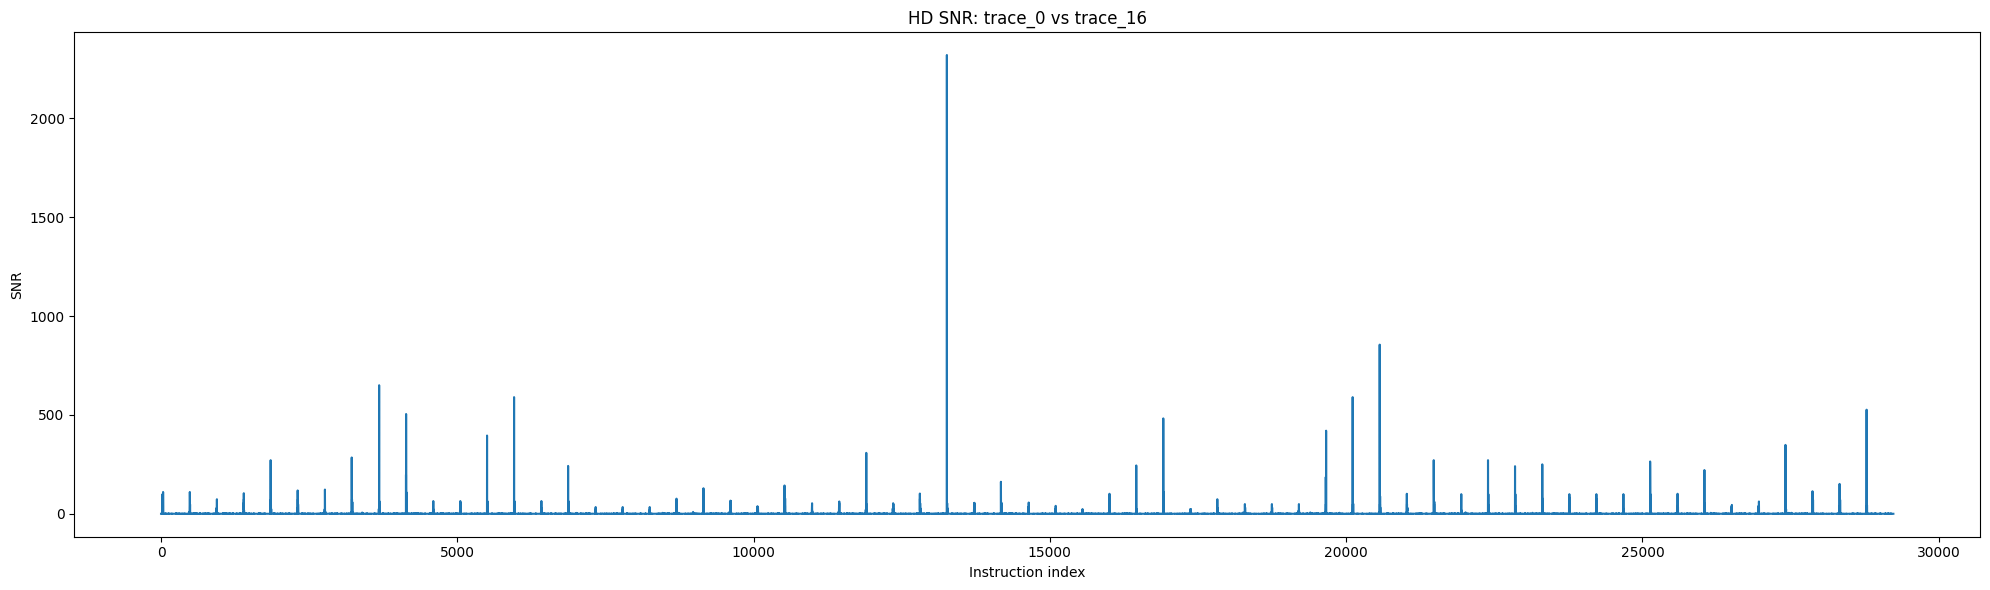

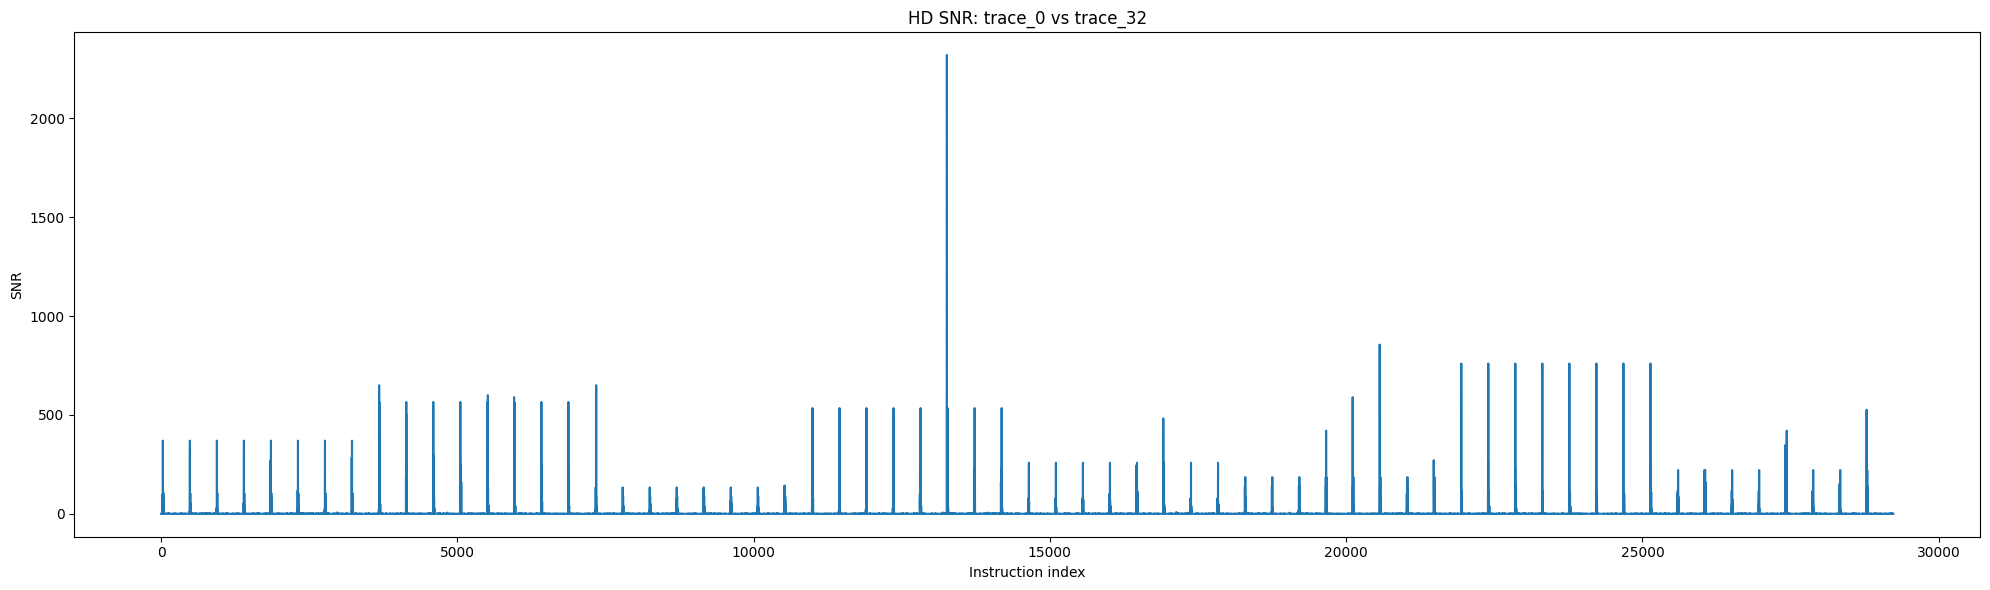

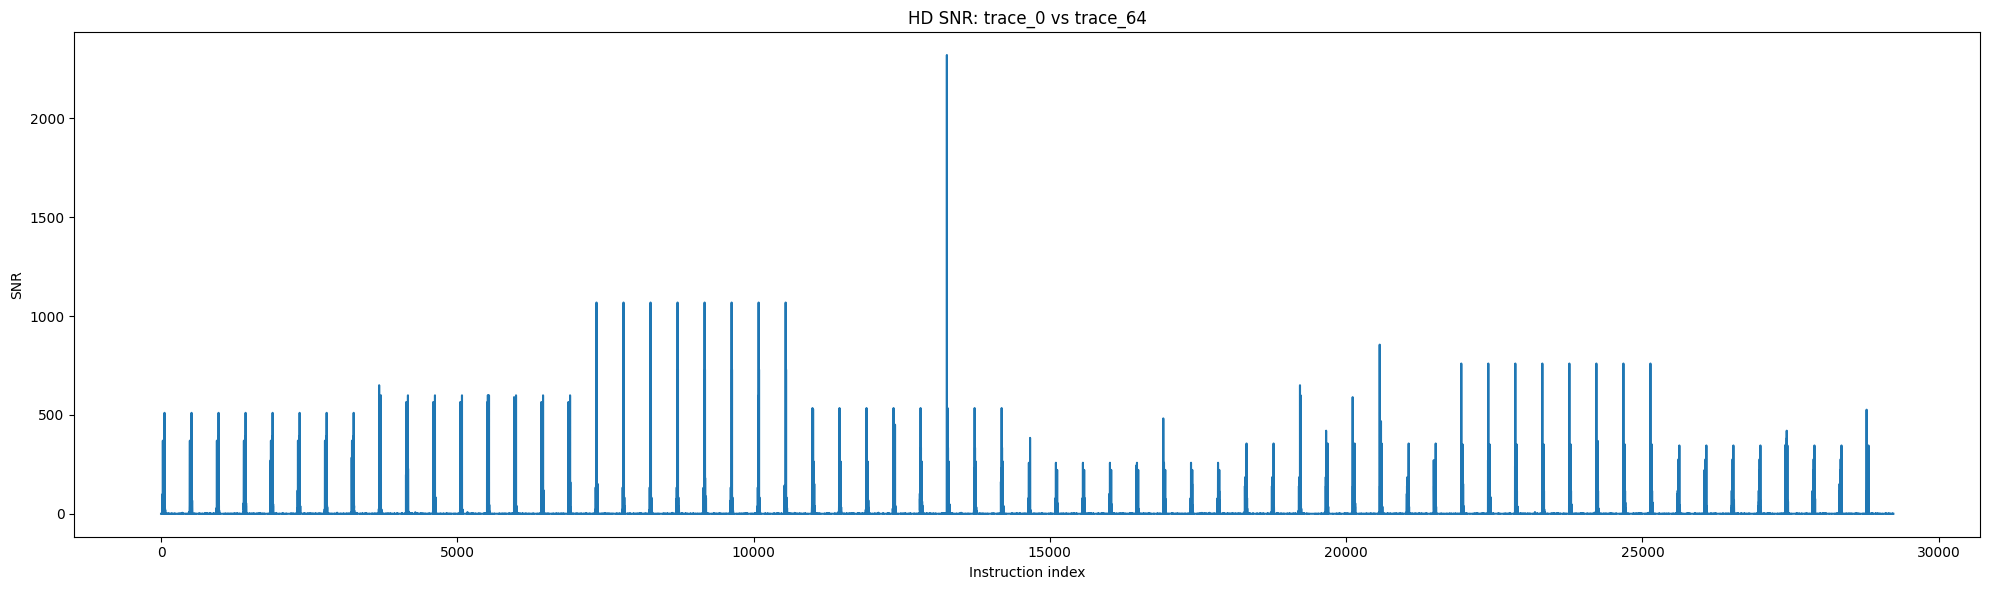

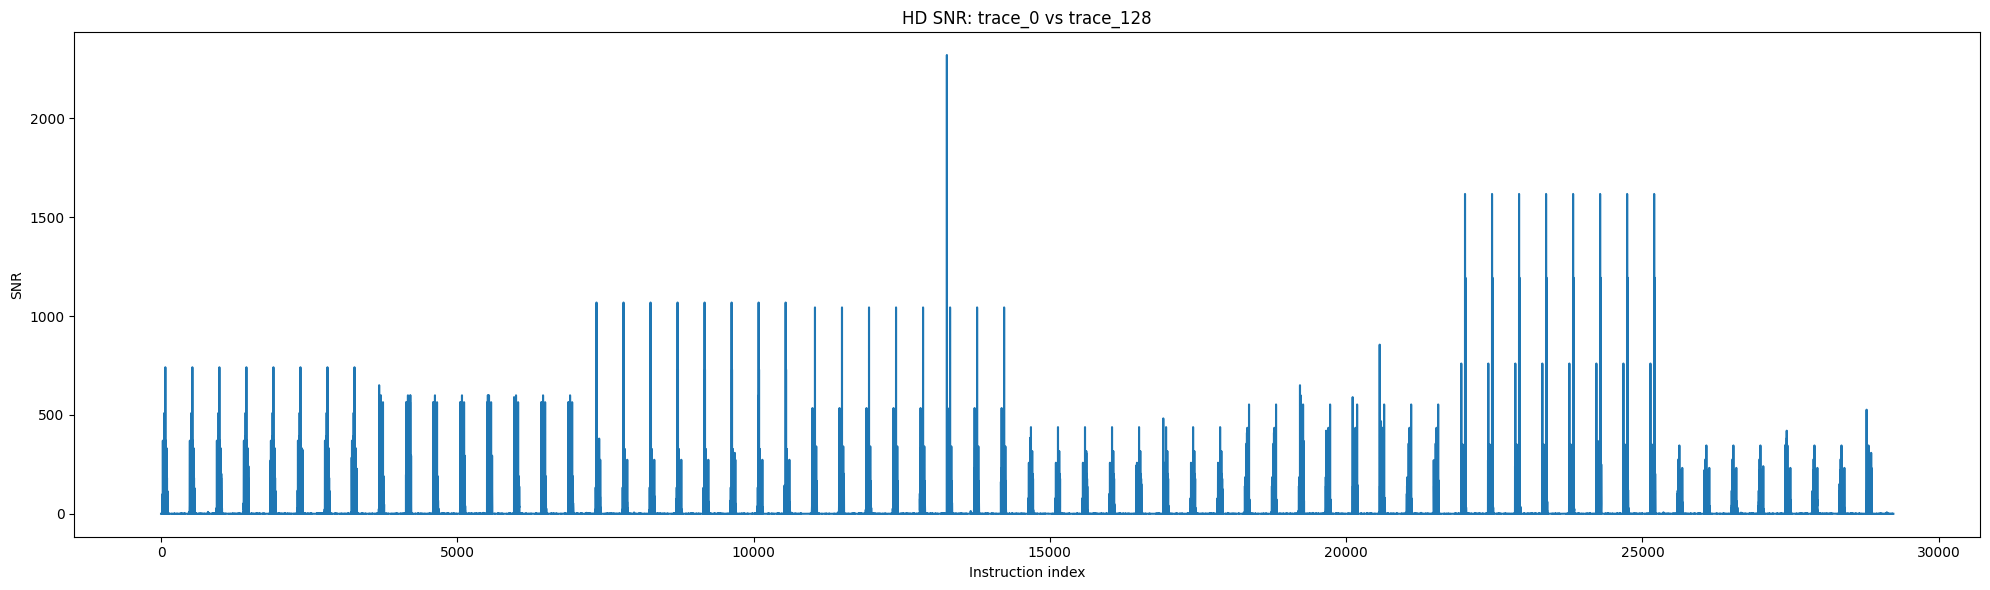

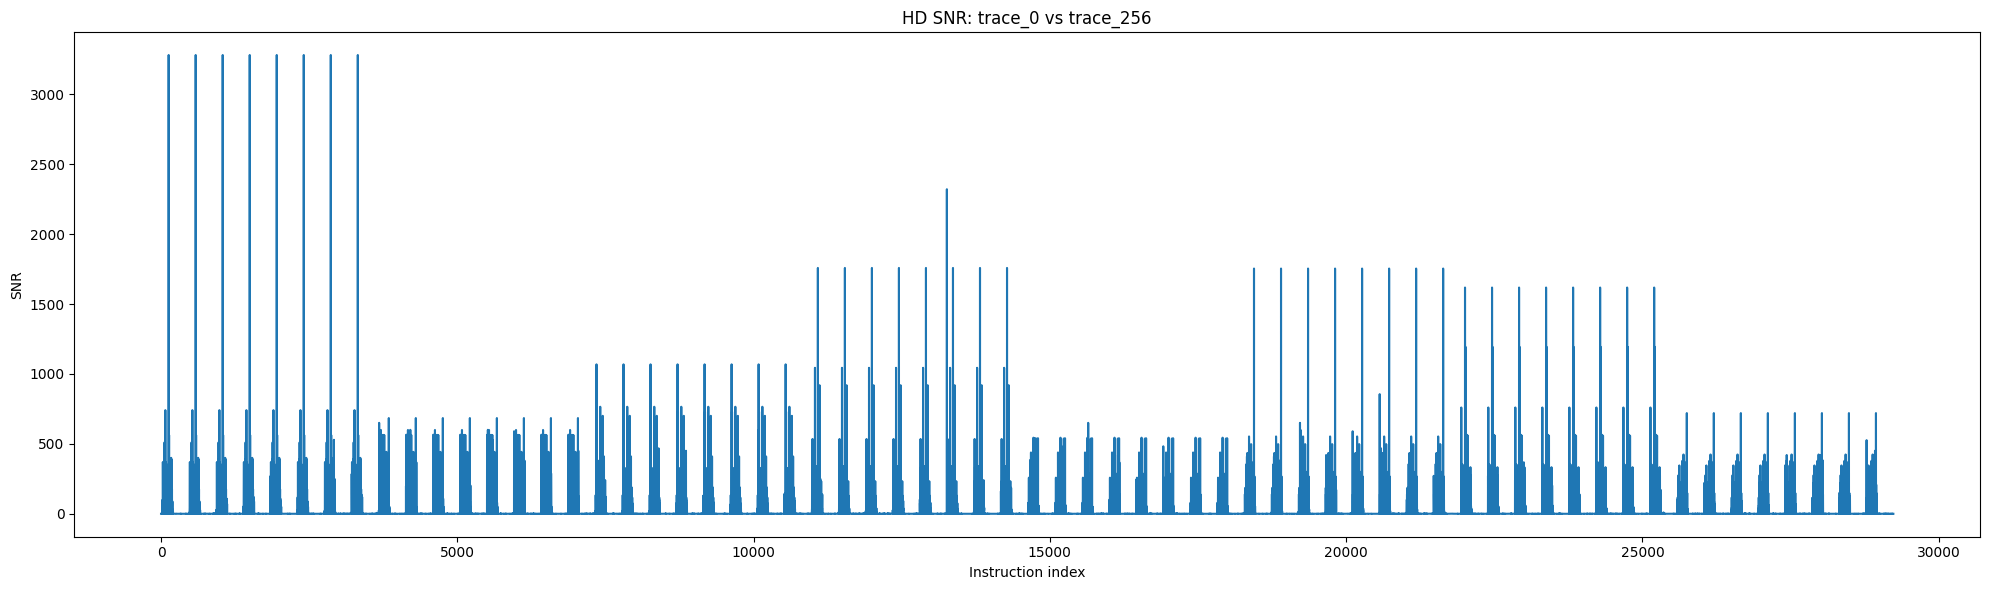

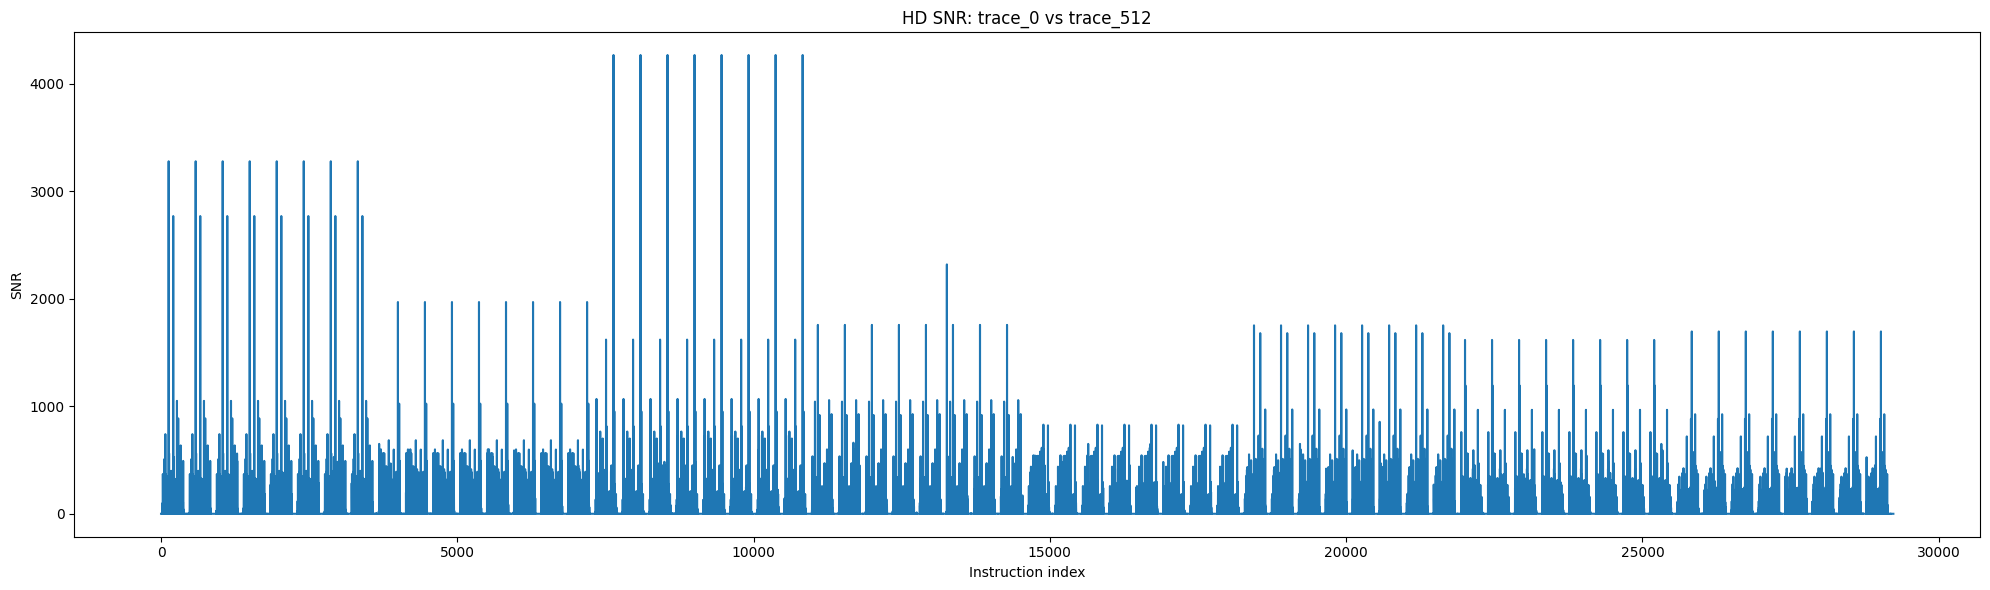

Number of traces to plot: 10
Trace lengths: {'trace_0 vs trace_1': 29236, 'trace_0 vs trace_2': 29236, 'trace_0 vs trace_4': 29236, 'trace_0 vs trace_8': 29236, 'trace_0 vs trace_16': 29236, 'trace_0 vs trace_32': 29236, 'trace_0 vs trace_64': 29236, 'trace_0 vs trace_128': 29236, 'trace_0 vs trace_256': 29236, 'trace_0 vs trace_512': 29236}
Plotting 'trace_0 vs trace_1': length=29236, alpha=1.00
Plotting 'trace_0 vs trace_2': length=29236, alpha=0.96
Plotting 'trace_0 vs trace_4': length=29236, alpha=0.92
Plotting 'trace_0 vs trace_8': length=29236, alpha=0.88
Plotting 'trace_0 vs trace_16': length=29236, alpha=0.84
Plotting 'trace_0 vs trace_32': length=29236, alpha=0.80
Plotting 'trace_0 vs trace_64': length=29236, alpha=0.76
Plotting 'trace_0 vs trace_128': length=29236, alpha=0.72
Plotting 'trace_0 vs trace_256': length=29236, alpha=0.68
Plotting 'trace_0 vs trace_512': length=29236, alpha=0.64


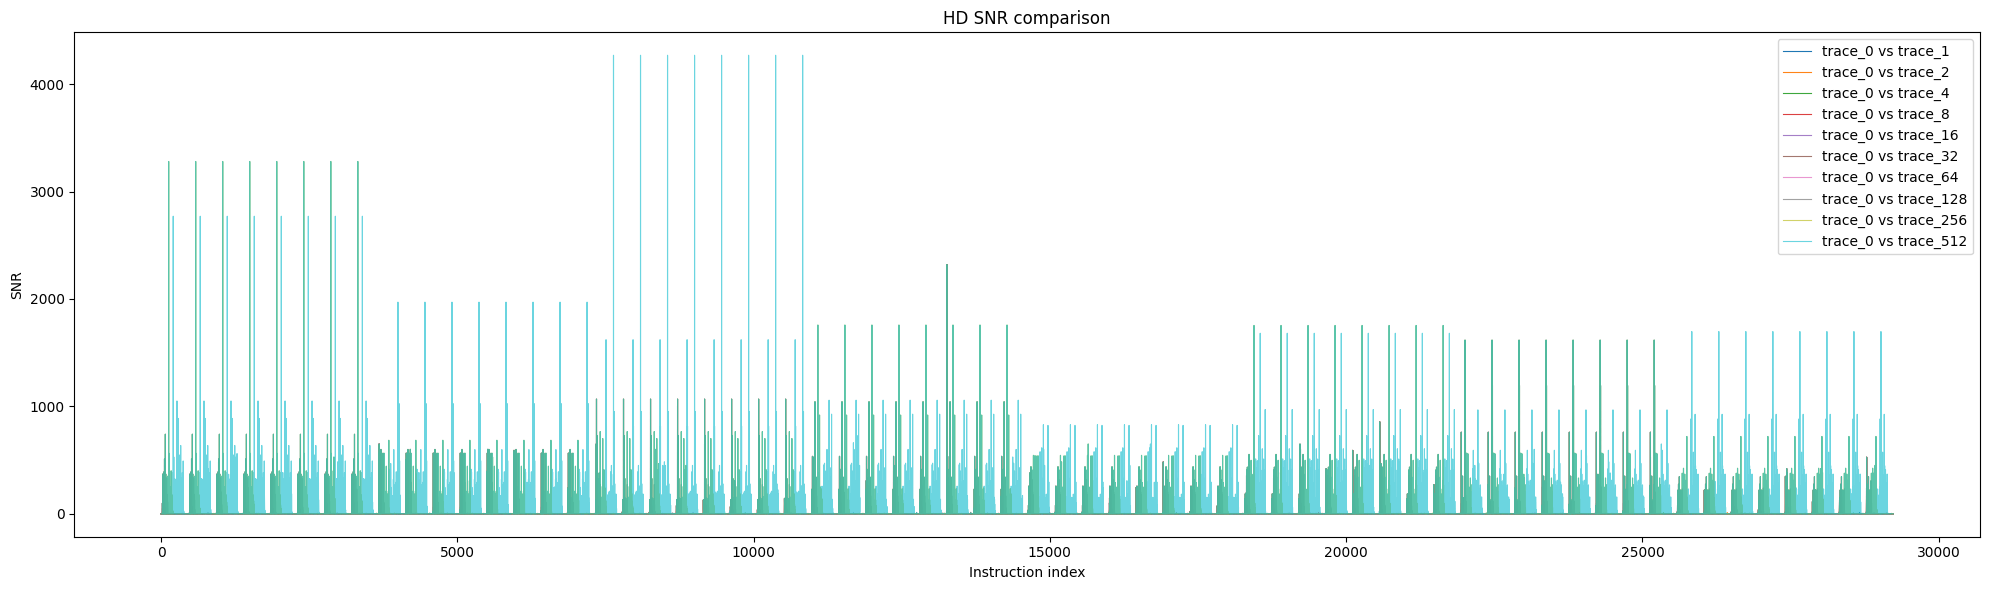

In [ ]:
based_index   = 0 
#load the base 
hw_base = load_trace(result_dir, "HW", based_index)
hd_base = load_trace(result_dir, "HD", based_index)

snr_hw = {}   # dictionary to store results for hw
snr_hd = {}   # dictionary to store results for hd
fault_index =[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

combined_index_key =  ["0_1", "0_2", "0_4"]

for alt in fault_index:
    hw_alt = load_trace(result_dir, "HW", alt)
    key = f"{based_index}_{alt}"  
    snr_hw[key] = compute_snr(hw_base, hw_alt)

filtered_snr_hw = {k: snr_hw[k] for k in combined_index_key if k in snr_hw}

for key, snr in filtered_snr_hw.items():
# for key, snr in snr_hw.items():
    plot_single(
        snr,
        f"HW SNR: trace_{key.replace('_',' vs trace_')}",
        os.path.join(result_dir, f"snr_HW_{key}.png")
    )

plot_combined(
    {f"trace_{k.replace('_',' vs trace_')}": v for k, v in filtered_snr_hw.items()},
    "HW SNR comparison",
    os.path.join(result_dir, "snr_HW_combined.png")
)


for alt in fault_index:
    hd_alt = load_trace(result_dir, "HD", alt)
    key = f"{based_index}_{alt}"  
    snr_hd[key] = compute_snr(hd_base, hd_alt)

# filtered_snr_hd = {k: snr_hd[k] for k in combined_index_key if k in snr_hd}
for key, snr in snr_hd.items():
    plot_single(
        snr,
        f"HD SNR: trace_{key.replace('_',' vs trace_')}",
        os.path.join(result_dir, f"snr_HD_{key}.png")
    )

plot_combined(
    {f"trace_{k.replace('_',' vs trace_')}": v for k, v in snr_hd.items()},
    "HD SNR comparison",
    os.path.join(result_dir, "snr_HD_combined.png")
)



# Create arithmetic visualisation 

In [ ]:
def return_instruction_type(instr):
    instr = str(instr).upper().strip()
    instr_base = instr.split('.')[0]

    arithmetic = {
        'ADC','ADCS','ADD','ADDS','ADDW',
        'SUB','SUBS','SUBW','SBC','SBCS','RSB','RSBS',
        'CMN','CMP','AND','ANDS','BIC','BICS',
        'EOR','EORS','ORN','ORNS','ORR','ORRS',
        'TEQ','TST','MOV','MOVS','MOVW','MOVT',
        'MVN','MVNS','LSL','LSLS','LSR','LSRS',
        'ASR','ASRS','ROR','RORS','RRX','RRXS',
        'CLZ','REV','REV16','REVSH','RBIT','ADR',
        'MUL','MULS','MLA','MLS','SDIV','UDIV',
        'SMULL','UMULL','SMLAL','UMLAL','UMAAL',
        'SMLAD','SMLADX','SMLABB','SMLABT','SMLATB','SMLATT',
        'QADD','QSUB','SSAT','USAT',
        'SXTB','SXTH','UXTB','UXTH','SBFX','UBFX'
    }

    load_store = {
        'LDR','LDRB','LDRH','LDRSB','LDRSH','LDRD','LDRT',
        'LDREX','LDREXB','LDREXH',
        'STR','STRB','STRH','STRD','STRT',
        'STREX','STREXB','STREXH',
        'LDM','LDMIA','LDMDB','LDMFD','LDMEA',
        'STM','STMIA','STMDB','STMFD','STMEA',
        'PUSH','POP'
    }

    branch_jump = {
        'B','BL','BX','BLX','CBZ','CBNZ','TBB','TBH',
        'BEQ','BNE','BCS','BCC','BMI','BPL',
        'BVS','BVC','BHI','BLS','BGE','BLT','BGT','BLE'
    }

    floating_point = {
        'VADD','VSUB','VMUL','VDIV','VABS','VCMP','VCMPE',
        'VCVT','VCVTR','VFMA','VFNMA','VFMS','VFNMS',
        'VLDR','VSTR','VLDM','VSTM','VMOV','VMRS','VMSR',
        'VNEG','VSQRT','VPOP','VPUSH'
    }

    system = {
        'BKPT','SVC','CPSID','CPSIE','DMB','DSB','ISB',
        'CLREX','MRS','MSR','NOP','SEV','WFE','WFI','IT'
    }

    if instr in arithmetic or instr_base in arithmetic:
        return "arithmetic"

    if instr in load_store or instr_base in load_store:
        return "load_store"

    if instr in branch_jump or instr_base in branch_jump:
        return "branch_jump"

    if instr in floating_point or instr_base in floating_point:
        return "floating_point"

    if instr in system or instr_base in system:
        return "system"

    return "other"



In [27]:
def plot_trace_with_arithmetic(csv_path, selected_registers, result_dir=None):

    df = pd.read_csv(csv_path)
    df.fillna('0x0', inplace=True)

    df["instruction_type"] = df["instruction"].apply(return_instruction_type)

    hw_trace = create_HW_trace(csv_path, selected_registers)
    hd_trace = create_HD_trace(csv_path, selected_registers)

    arithmetic_idx_hw = df.index[df["instruction_type"] == "arithmetic"].to_numpy()
    arithmetic_idx_hd = arithmetic_idx_hw[arithmetic_idx_hw < len(hd_trace)]

    plt.close('all')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 10), sharex=True)

    ax1.plot(hw_trace, alpha=0.7, label="HW trace")
    ax1.scatter(
        arithmetic_idx_hw,
        hw_trace[arithmetic_idx_hw],
        s=10,
        label="Arithmetic instructions"
    )
    ax1.set_title("HW Trace with Arithmetic Instructions")
    ax1.set_ylabel("HW value")
    ax1.legend()

    ax2.plot(hd_trace, alpha=0.7, label="HD trace")
    ax2.scatter(
        arithmetic_idx_hd,
        hd_trace[arithmetic_idx_hd],
        s=10,
        label="Arithmetic instructions"
    )
    ax2.set_title("HD Trace with Arithmetic Instructions")
    ax2.set_xlabel("Instruction index")
    ax2.set_ylabel("HD value")
    ax2.legend()

    plt.tight_layout()

    if result_dir is not None:
        save_path = os.path.join(result_dir, "trace_with_arithmetic.png")
        plt.savefig(save_path, dpi=200)

    plt.show()

    return df, hw_trace, hd_trace

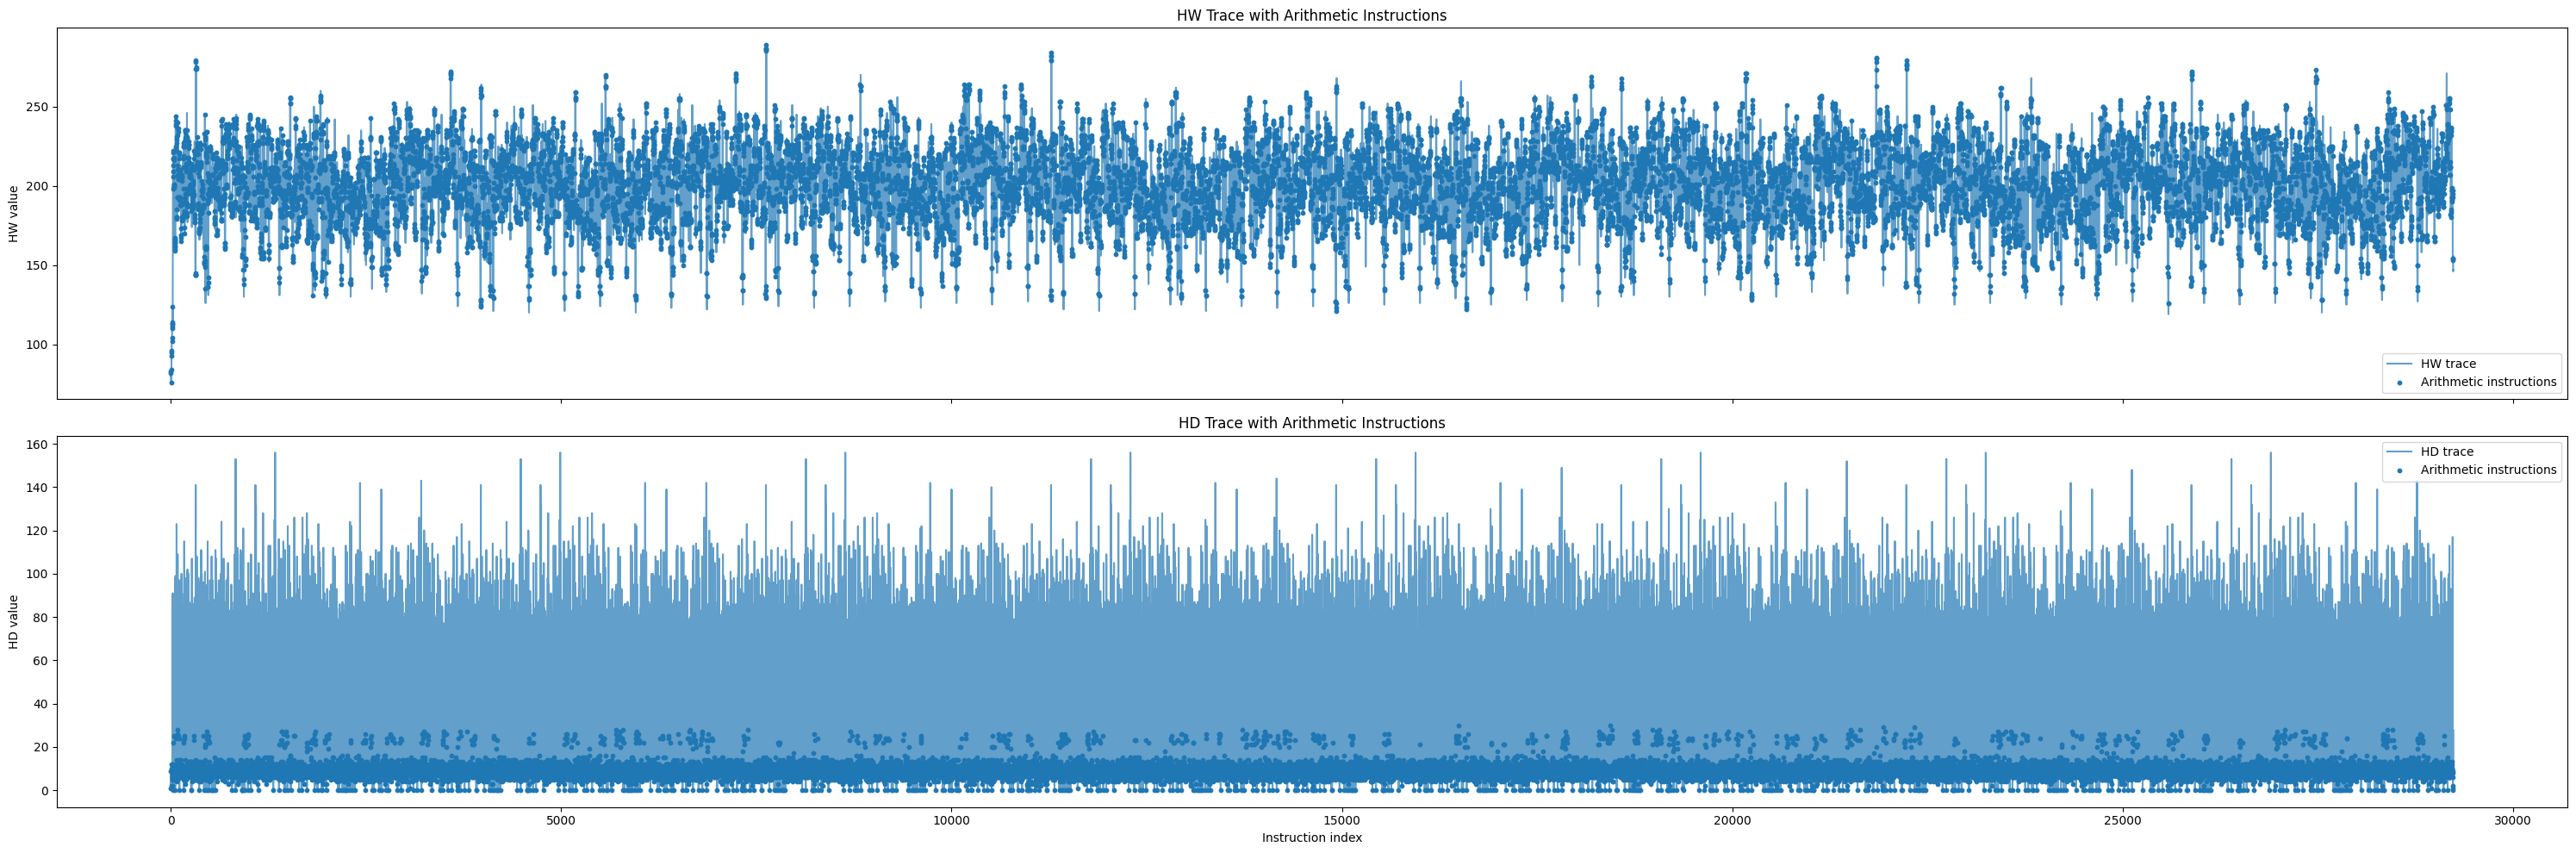

In [29]:
csv_path = "output_decapsulation_sample/Run_1/Trace_0/trace_0.csv"
result_dir = "Results_arithmetic"
os.makedirs(result_dir, exist_ok=True)
df_full, hw_trace, hd_trace = plot_trace_with_arithmetic(
    csv_path,
    selected_registers,
    result_dir
)